In [ ]:
# Resources
# If not in Google Colab, ignore this cell.
# If in Google Colab: Please uncomment the line below and run this cell first to clone the repository so that the dataset can be accessed.
# !git clone https://github.com/ezraalejandre/Building-Tomorrow.git

# Phase 1 - Business Understanding


## Project Title: **Real Estate Project Risk Analysis & Cost Prediction**
### Define a real-world problem aligned with the SDGs that predictive analytics can address:
### - **SDG 11**: Sustainable Cities and Communities - Ensuring efficient urban development
### - **SDG 9**: Industry, Innovation and Infrastructure - Building resilient infrastructure
## **Business Problem:** Real estate projects face significant risks of delays and cost overruns.
## This analysis will:
### 1. *Classify* projects at risk of delays (Classification)
### 2. *Cluster* projects based on scale and cost to identify project types (Clustering)
### 3. *Forecast* total project costs over time (Time Series)

# Phase 2 - Data Understanding

## 2.1 Import Libraries

In [5]:
# ═══════════════════════════════════════════════════════════════════
# Import all required libraries
# ═══════════════════════════════════════════════════════════════════

# ── Core ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Statistical Tests ────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from scipy.stats import boxcox, normaltest, shapiro

# ── Forecasting Models ───────────────────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Optional — install first: pip install pmdarima
# from pmdarima import auto_arima
# Optional — install first: pip install prophet
# from prophet import Prophet

# ── Classification Models ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# ── Clustering Models ────────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# ── Preprocessing & Model Selection ──────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# ── Evaluation Metrics ───────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, silhouette_score, davies_bouldin_score

# ── Iteration tools ──────────────────────────────────────────────────
import itertools
import warnings
warnings.filterwarnings('ignore')

# ── Global Plot Settings ─────────────────────────────────────────────
plt.rcParams['figure.figsize']  = (14, 5)
plt.rcParams['axes.grid']       = True
plt.rcParams['grid.alpha']      = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries loaded.")


✅ All libraries loaded.


## 2.2 Load Dataset

In [6]:
# ═══════════════════════════════════════════════════════════════════
# Load dataset
# ═══════════════════════════════════════════════════════════════════
# If in Local: Please uncomment the line below this and run this cell first so that the dataset can be accessed.
# df = pd.read_csv('dataset/ProjectInfo_Gujarat.csv')
# If in Colab: Please uncomment the line below this and run this cell first so that the dataset can be accessed.
# df = pd.read_csv('/content/Building-Tomorrow/dataset/ProjectInfo_Gujarat.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
display(df.head(5))
display(df.tail(5))

Dataset shape: (14507, 44)
Columns      : ['projectRegId', 'projectName', 'promoterName', 'projectType', 'promoterType', 'architect_name', 'eng_name', 'projectAddress', 'projectAddress2', 'pinCode', 'tPNo', 'underRedevelopment', 'distName', 'tpo_code', 'startDate', 'location_coordinates', 'startProjectYear', 'startProjectMonth', 'completionDate', 'EndProjectYear', 'EndProjectMonth', 'totalProjects', 'totalUnits', 'bookedUnits', 'noOfInventory', 'avgUnits', 'totalEstimatedCost', 'totalIncurredCost', 'totalPayableAmountGovernment', 'totalDevelopCost', 'totalSellingAmount', 'bookedSellingAmount', 'totalReceivedAmount', 'bookedReceivedAmount', 'totalLandCost', 'avgEstimatedCost_AllProjects', 'totalCarpetArea_form3A', 'totalBuiltupArea_form3A', 'totalSquareFootBuild', 'AvgSquareFootBuild', 'avgCostPerSqFt', 'avgCostPerUnit', 'totalAreaOfLand', 'AvgAreaOfLand']


,projectRegId,projectName,promoterName,projectType,promoterType,architect_name,eng_name,projectAddress,projectAddress2,pinCode,...,totalLandCost,avgEstimatedCost_AllProjects,totalCarpetArea_form3A,totalBuiltupArea_form3A,totalSquareFootBuild,AvgSquareFootBuild,avgCostPerSqFt,avgCostPerUnit,totalAreaOfLand,AvgAreaOfLand
0,7871,SURAT DIAMOND BOURSE,SDB DIAMOND BOURSE,Commercial,COMPANY,MORPHOGENESIS,JW CONSULTANTS LLP,"BLOCK NO.177, VILLAGE KHAJOD, TALUKA MAJURA",SURAT,394550.0,...,6.680442e+09,2.769942e+10,196471.066549,196471.066549,196471.07,196471.07,140984.730922,5.773118e+06,143825.4,143825.4
1,1109,GLOBALE TEXTILE MARKET,GLOBALE INFRASPACE LLP,Commercial,LIMITED LIABILITY PARTNERSHIP FIRM,NaN,NaN,GLOBALE TEXTILE MARKET,"UMARWADA, KADODARA ROAD, SURAT",395006.0,...,3.660000e+09,7.110000e+09,636192.000000,636192.000000,636192.00,636192.00,11175.871435,1.893980e+06,NaN,NaN
2,4258,68 SHOPS + 1228 LIG-2 + 432 MIG-1 AT GOTA,GUJARAT HOUSING BOARD,Mixed Development,COMPETENT AUTHORITY/ GOVERNMENT,MAMTA SHAH & ASSOCIATES,DELF CONSULTING ENGINEERS (INDIA) PVT. LTD.,VASANTNAGAR TOWNSHIP,"GOTA OGNAJ ROAD, GOTA",380060.0,...,2.308993e+06,2.045715e+09,174950.560000,336330.720000,174950.56,174950.56,11693.105144,5.919315e+05,NaN,NaN
3,5212,SHREE KUBERJI VALENTINE TEXTILE MARKET,SHREE KUBERJI BUILDCON,Commercial,PARTNERSHIP FIRM,NaN,NaN,"BLOCK NO:258-259,TP:35,SAROLI-KUMBHARIYA","OPP.BHARAT CANCER HOSPITAL,SURAT KADODARA ROAD",NaN,...,3.775819e+08,2.448422e+09,46423.440000,46423.440000,46423.44,46423.44,52741.069942,7.651318e+05,13277.3,13277.3
4,10965,Construction of EWS - I and EWS-II (2560 HOUS...,SURAT URBAN DEVELOPMENT AUTHORITY,Residential/Group Housing,COMPETENT AUTHORITY/ GOVERNMENT,KIRTI PATEL,KIRTI PATEL,TP SCHEME NO 30 AT VANAKLA,FINAL PLOT NUMBER 129,NaN,...,0.000000e+00,2.394000e+09,94350.080000,94350.080000,94350.08,94350.08,25373.587389,9.351562e+05,50756.0,50756.0


,projectRegId,projectName,promoterName,projectType,promoterType,architect_name,eng_name,projectAddress,projectAddress2,pinCode,...,totalLandCost,avgEstimatedCost_AllProjects,totalCarpetArea_form3A,totalBuiltupArea_form3A,totalSquareFootBuild,AvgSquareFootBuild,avgCostPerSqFt,avgCostPerUnit,totalAreaOfLand,AvgAreaOfLand
14502,3387,SHUBH RESIDENCY,SHUBH DEVELOPERS,Residential/Group Housing,PARTNERSHIP FIRM,KALPEN M HARSORA,BHUPATBHAI P VITHANI,"FP:158,TP:51(DABHOLI,","RS NO:127,NEAR-DABHOLI JAHANGIRPURA BRIDGE",395004.0,...,15727852.0,106298174.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14503,3398,RANIP PURNIMA CO-OPERATIVE HOUSING SOCIETY LIM...,SHREE UMA DEVELOPERS,Residential/Group Housing,PARTNERSHIP FIRM,DILIP RAMANBHAI PATEL,AHMADUSEN Y CHHIPA,RANIP PURNIMA CO-OPERATIVE HOUSING SOCIETY LIM...,"RANIP, AHMEDABAD",382480.0,...,2138802.0,35670802.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14504,4160,SUNDAY LAGOON,SUNDAY LAGOON,Residential/Group Housing,PARTNERSHIP FIRM,ASHVINBHAI DOBARIYA,Vrajlal ambaliya,"150FT CANAL ROAD, NEAR AMBIKA HEIGHTS","GODADRA DINDOLI ROAD, 395010",395012.0,...,15541110.0,173382613.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14505,4351,SGBUSINESSHUB,DEV DEVELOPERS,Commercial,PARTNERSHIP FIRM,MR SAURABH VERMA,UMANG J PATEL,SG BUSINESSHUB NR GOTA OVERBRIDGE,S G HIGHWAY,380060.0,...,361626873.0,908596876.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14506,5466,SHIVALIK AVENUE,TUSHAR LABHUBHAI KASODARIA PROPRIETOR OF M/S. ...,Commercial,Individual/Propritorship,VIJAY.C.SHAH,VIJAY.C.SHAH,SHIVALIK AVENUE OPP-REGIONAL PASSPORT OFFICE,UDHNA DARWAJA,395002.0,...,85205000.0,251229827.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.3 Initial Structural Inspection

In [ ]:
# ====================================================
# DATASET OVERVIEW
# ====================================================

print("=" * 55)
print(" DATA TYPES & NON-NULL COUNTS")
print("=" * 55)

df.info()

# ====================================================
# DATASET SHAPE
# ====================================================

print(f"\nRows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# ====================================================
# DUPLICATE CHECK
# ====================================================

print(f"\nDuplicate rows: {df.duplicated().sum()}")

# ====================================================
# IMPORTANT COLUMNS
# ====================================================

DATE_COLUMN = 'startDate'

# Classification target
CLASS_TARGET = 'projectType'

# Time series target
TS_TARGET = 'totalEstimatedCost'

# Clustering features
CLUSTER_FEATURES = [
    'totalUnits',
    'totalEstimatedCost',
    'totalCarpetArea_form3A'
]

print(f"\nDate column: {DATE_COLUMN}")
print(f"Classification target: {CLASS_TARGET}")
print(f"Time series target: {TS_TARGET}")
print(f"Clustering features: {CLUSTER_FEATURES}")

 DATA TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14507 entries, 0 to 14506
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   projectRegId                  14507 non-null  int64  
 1   projectName                   14507 non-null  object 
 2   promoterName                  14506 non-null  object 
 3   projectType                   14507 non-null  object 
 4   promoterType                  14507 non-null  object 
 5   architect_name                9801 non-null   object 
 6   eng_name                      9641 non-null   object 
 7   projectAddress                13631 non-null  object 
 8   projectAddress2               13388 non-null  object 
 9   pinCode                       7710 non-null   float64
 10  tPNo                          7054 non-null   object 
 11  underRedevelopment            14505 non-null  object 
 12  distName                      

## 2.4 Descriptive Statistics

In [ ]:
# ====================================================
# DESCRIPTIVE STATISTICS
# ====================================================

print("=" * 55)
print(" DESCRIPTIVE STATISTICS")
print("=" * 55)

display(df.describe(include='all').T)

# ====================================================
# NUMERIC FEATURES SUMMARY
# ====================================================

numeric_cols = df.select_dtypes(include=['number']).columns

print("\nNumeric Columns:")
print(list(numeric_cols))

# ====================================================
# CLASSIFICATION TARGET ANALYSIS
# ====================================================

print("\n" + "=" * 55)
print(" CLASSIFICATION TARGET DISTRIBUTION")
print("=" * 55)

class_target = df[CLASS_TARGET].dropna()

print(f"\nClassification Target: '{CLASS_TARGET}'")
print(class_target.value_counts())

print("\nClass Percentages:")
print(class_target.value_counts(normalize=True) * 100)

# ====================================================
# TIME SERIES TARGET ANALYSIS
# ====================================================

print("\n" + "=" * 55)
print(" TIME SERIES TARGET SUMMARY")
print("=" * 55)

ts_target = pd.to_datetime(df[TS_TARGET].dropna(), errors='coerce')
ts_target = ts_target.dropna() # Drop any dates that failed conversion

print(f"\nTime Series Target: '{TS_TARGET}'")

# Only calculate and print if ts_target is not empty
if not ts_target.empty:
    print(f"  Mean              : {ts_target.mean()}")
    print(f"  Median            : {ts_target.median()}")
    print(f"  Min               : {ts_target.min()}")
    print(f"  Max               : {ts_target.max()}")

    # Std Dev for datetime series results in a Timedelta
    # Skewness and Kurtosis are not directly meaningful for datetime objects
    # Coefficient of Variation usually applies to ratios, not raw dates
    if ts_target.dtype == '<M8[ns]': # Check if it's a datetime type
        time_diffs = (ts_target - ts_target.min()).dt.days
        if not time_diffs.empty:
            std_dev_days = time_diffs.std()
            print(f"  Std Dev (days)    : {std_dev_days:.4f}")
    else:
        # For numerical targets that might appear here
        if ts_target.mean() != 0:
            print(f"  Std Dev           : {ts_target.std():.4f}")
            cv = ts_target.std() / ts_target.mean() * 100
            print(f"  Coefficient of Var: {cv:.2f}%")
        print(f"  Skewness          : {ts_target.skew():.4f}")
        print(f"  Kurtosis          : {ts_target.kurt():.4f}")
else:
    print("  No valid datetime values to calculate statistics.")

# ====================================================
# CLUSTERING FEATURES SUMMARY
# ====================================================

print("\n" + "=" * 55)
print(" CLUSTERING FEATURE SUMMARY")
print("=" * 55)

display(df[CLUSTER_FEATURES].describe().T)

 DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
projectRegId,14507.0,NaN,NaN,NaN,11133.280003,6418.551335,12.0,6061.5,10399.0,17356.5,24634.0
projectName,14507,13583,OM RESIDENCY,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promoterName,14506,10196,SHREEJI DEVELOPERS,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
projectType,14507,4,Residential/Group Housing,6677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promoterType,14507,11,PARTNERSHIP FIRM,10525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
architect_name,9801,4131,CHETAN PANCHOLI,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eng_name,9641,3890,ZARNA ASSOCIATES,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
projectAddress,13631,13460,Shantigram,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
projectAddress2,13388,11800,,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pinCode,7710.0,NaN,NaN,NaN,382288.148638,11194.631044,350055.0,380049.0,382428.0,391101.0,396450.0



Numeric Columns:
['projectRegId', 'pinCode', 'startProjectYear', 'startProjectMonth', 'EndProjectYear', 'EndProjectMonth', 'totalProjects', 'totalUnits', 'bookedUnits', 'noOfInventory', 'avgUnits', 'totalEstimatedCost', 'totalIncurredCost', 'totalPayableAmountGovernment', 'totalDevelopCost', 'totalSellingAmount', 'bookedSellingAmount', 'totalReceivedAmount', 'bookedReceivedAmount', 'totalLandCost', 'avgEstimatedCost_AllProjects', 'totalCarpetArea_form3A', 'totalBuiltupArea_form3A', 'totalSquareFootBuild', 'AvgSquareFootBuild', 'avgCostPerSqFt', 'avgCostPerUnit', 'totalAreaOfLand', 'AvgAreaOfLand']

 CLASSIFICATION TARGET DISTRIBUTION

Classification Target: 'projectType'
projectType
Residential/Group Housing    6677
Mixed Development            4974
Commercial                   2086
Plotted Development           770
Name: count, dtype: int64

Class Percentages:
projectType
Residential/Group Housing    46.026056
Mixed Development            34.286896
Commercial                   14.379

,count,mean,std,min,25%,50%,75%,max
totalUnits,14486.0,1.202094e+02,1.626120e+02,1.0,3.200000e+01,7.300000e+01,1.540000e+02,4.798000e+03
totalEstimatedCost,14505.0,3.259395e+08,6.044184e+08,300000.0,6.241800e+07,1.646995e+08,3.576822e+08,2.769942e+10
totalCarpetArea_form3A,14486.0,8.643981e+03,1.537527e+04,71.0,2.281253e+03,5.322730e+03,1.048644e+04,7.780040e+05


## 2.5 Visual Exploratory Data Analysis

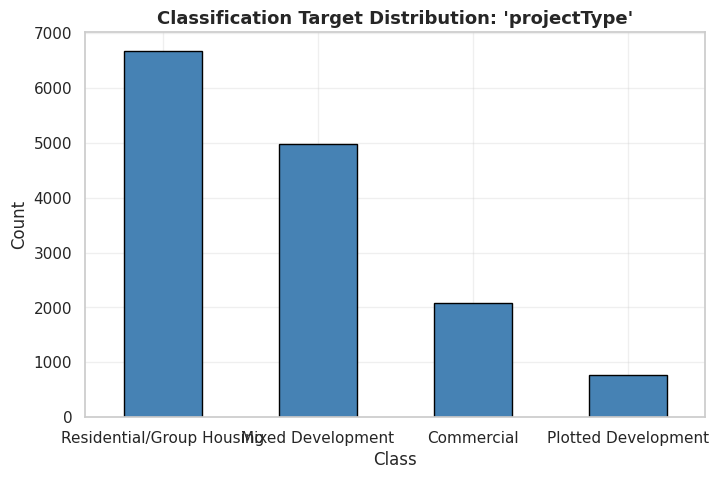


Class Distribution (%):
projectType
Residential/Group Housing    46.03
Mixed Development            34.29
Commercial                   14.38
Plotted Development           5.31
Name: count, dtype: float64


In [ ]:
# ====================================================
# CLASSIFICATION TARGET DISTRIBUTION
# ====================================================

class_counts = df[CLASS_TARGET].value_counts()

plt.figure(figsize=(8, 5))

class_counts.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title(
    f"Classification Target Distribution: '{CLASS_TARGET}'",
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Class')
plt.ylabel('Count')

plt.xticks(rotation=0)

plt.show()

# Print proportions
print("\nClass Distribution (%):")
print((class_counts / class_counts.sum() * 100).round(2))

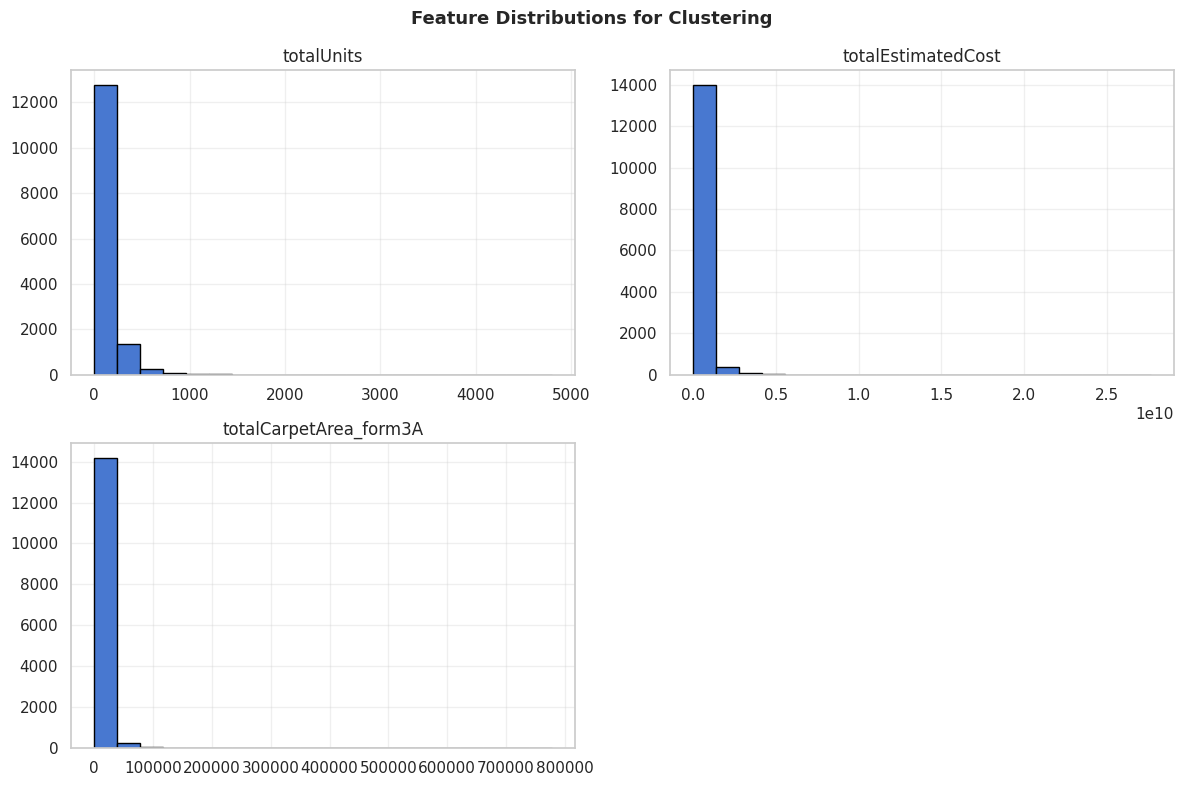

In [ ]:
# ====================================================
# CLUSTERING FEATURE DISTRIBUTIONS
# ====================================================

cluster_features = df[CLUSTER_FEATURES]

cluster_features.hist(
    figsize=(12, 8),
    bins=20,
    edgecolor='black'
)

plt.suptitle(
    "Feature Distributions for Clustering",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

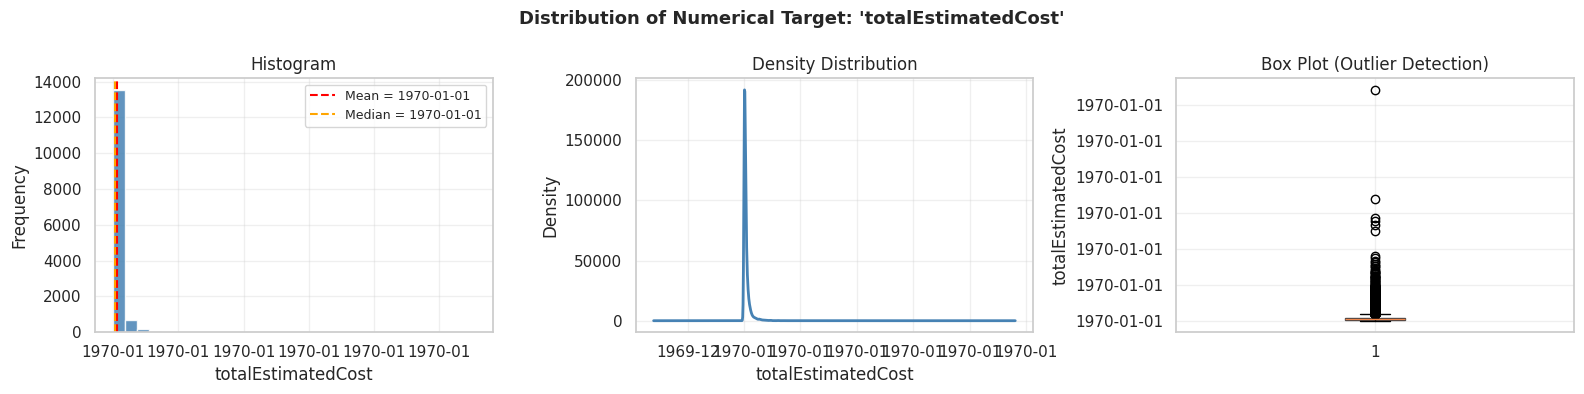

In [ ]:
# ====================================================
# TIME SERIES / NUMERICAL TARGET DISTRIBUTION
# ====================================================

target_raw = df[TS_TARGET]
# Convert to datetime objects and drop any NaT values
target_raw = pd.to_datetime(target_raw, errors='coerce').dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

fig.suptitle(
    f"Distribution of Numerical Target: '{TS_TARGET}'",
    fontsize=13,
    fontweight='bold'
)

# Histogram
axes[0].hist(
    target_raw,
    bins=30,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

# Format datetime for axvline labels
axes[0].axvline(
    target_raw.mean(),
    color='red',
    linestyle='--',
    label=f'Mean = {target_raw.mean().strftime("%Y-%m-%d")}'
)

axes[0].axvline(
    target_raw.median(),
    color='orange',
    linestyle='--',
    label=f'Median = {target_raw.median().strftime("%Y-%m-%d")}'
)

axes[0].set_title('Histogram')
axes[0].set_xlabel(TS_TARGET)
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)
# Use a date formatter for the x-axis
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# KDE
# Convert datetime to numerical format for KDE
pd.Series(mdates.date2num(target_raw)).plot.kde(
    ax=axes[1],
    color='steelblue',
    linewidth=2
)

axes[1].set_title('Density Distribution')
axes[1].set_xlabel(TS_TARGET)
# Use a date formatter for the x-axis
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Boxplot
# Convert datetime to numerical format for boxplot
axes[2].boxplot(
    mdates.date2num(target_raw), # Convert datetime to numerical format
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7)
)

# Set appropriate y-axis labels as dates
axes[2].yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[2].set_title('Box Plot (Outlier Detection)')
axes[2].set_ylabel(TS_TARGET)

plt.tight_layout()
plt.show()

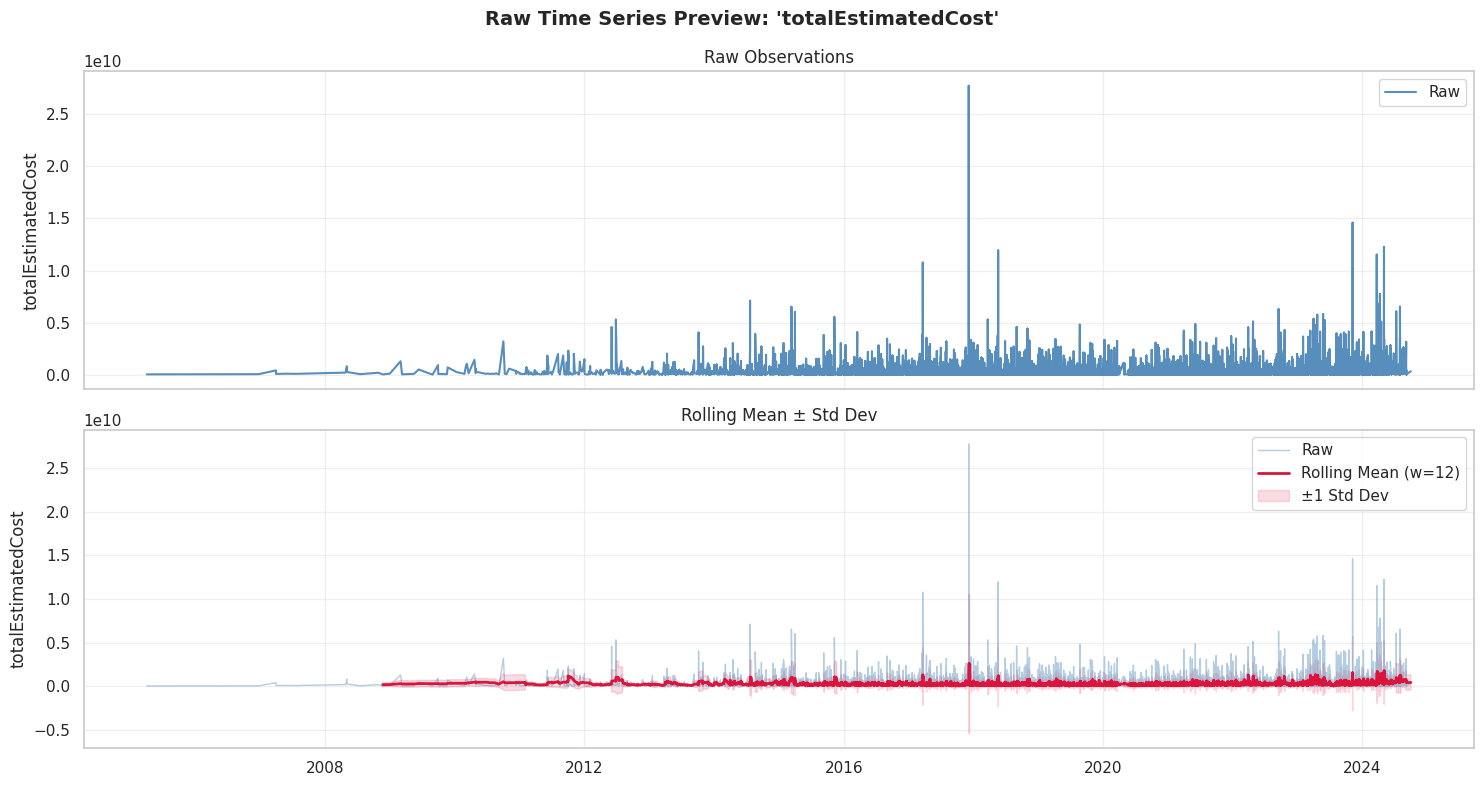

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Ensuring parsed Date Column
# ═══════════════════════════════════════════════════════════════════

df_preview = df.copy()
df_preview[DATE_COLUMN] = pd.to_datetime(df_preview[DATE_COLUMN], errors='coerce')
df_preview = df_preview.sort_values(DATE_COLUMN)

# Define TARGET_COLUMN as TS_TARGET for plotting purposes
TARGET_COLUMN = TS_TARGET

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle(f"Raw Time Series Preview: '{TARGET_COLUMN}'",
             fontsize=14, fontweight='bold')

# ── Raw series ───────────────────────────────────────────────────────
axes[0].plot(df_preview[DATE_COLUMN], df_preview[TARGET_COLUMN],
             color='steelblue', linewidth=1.5, alpha=0.9, label='Raw')
axes[0].set_ylabel(TARGET_COLUMN)
axes[0].set_title('Raw Observations')
axes[0].legend()

# ── Rolling statistics ───────────────────────────────────────────────
WINDOW = 12 # Default window size set to 12

rolling_mean = df_preview[TARGET_COLUMN].rolling(window=WINDOW).mean()
rolling_std  = df_preview[TARGET_COLUMN].rolling(window=WINDOW).std()

axes[1].plot(df_preview[DATE_COLUMN], df_preview[TARGET_COLUMN],
             color='steelblue', linewidth=1, alpha=0.4, label='Raw')
axes[1].plot(df_preview[DATE_COLUMN], rolling_mean,
             color='crimson', linewidth=2, label=f'Rolling Mean (w={WINDOW})')
axes[1].fill_between(df_preview[DATE_COLUMN],
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     color='crimson', alpha=0.15, label=f'±1 Std Dev')
axes[1].set_ylabel(TARGET_COLUMN)
axes[1].set_title('Rolling Mean ± Std Dev')
axes[1].legend()

plt.tight_layout()
plt.show()

# Phase 3 - Data Preparation

## 3.1 Global Cleaning

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Global Cleaning: Steps applicable to Classification, Clustering, and Time Series
# ═══════════════════════════════════════════════════════════════════

# Create a copy of the original DataFrame to work with
df_cleaned = df.copy()

# 1. Standardize column names to snake_case
# This helps maintain consistency and ease of access
df_cleaned.columns = df_cleaned.columns.str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True).str.lower()

# 2. Drop columns with excessive missing values (e.g., > 30-40% missing)
# These columns are often difficult to impute reliably without domain-specific knowledge
cols_to_drop = [
    'architect_name',         # ~67% missing
    'eng_name',               # ~66% missing
    'pin_code',               # ~53% missing
    't_p_no',                 # ~51% missing
    'total_area_of_land',     # ~39% missing
    'avg_area_of_land',
    'location_coordinates'    # Complex data type, difficult for general imputation
]
df_cleaned = df_cleaned.drop(columns=[col for col in cols_to_drop if col in df_cleaned.columns])

# 3. Convert date columns to datetime objects
# Essential for any time-based analysis and proper handling
date_cols = ['start_date', 'completion_date']
for col in date_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')

# 4. Impute missing values for remaining columns
# Numerical columns will be imputed with their median (robust to outliers)
# Categorical columns will be imputed with their mode (most frequent category)

numerical_cols = df_cleaned.select_dtypes(include=np.number).columns
categorical_cols = df_cleaned.select_dtypes(include='object').columns

# Impute numerical columns with median
for col in numerical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)

# Impute categorical columns with mode
for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)

# Re-derive year and month columns to ensure consistency with cleaned date columns
# This handles cases where original year/month columns were missing or inconsistent
if 'start_project_year' in df_cleaned.columns and 'start_date' in df_cleaned.columns:
    df_cleaned['start_project_year'] = df_cleaned['start_date'].dt.year
if 'start_project_month' in df_cleaned.columns and 'start_date' in df_cleaned.columns:
    df_cleaned['start_project_month'] = df_cleaned['start_date'].dt.month
if 'end_project_year' in df_cleaned.columns and 'completion_date' in df_cleaned.columns:
    df_cleaned['end_project_year'] = df_cleaned['completion_date'].dt.year
if 'end_project_month' in df_cleaned.columns and 'completion_date' in df_cleaned.columns:
    df_cleaned['end_project_month'] = df_cleaned['completion_date'].dt.month

# Ensure year/month columns are imputed if any NaNs remain after re-derivation (e.g., if date conversion failed for a row)
for col in ['start_project_year', 'start_project_month', 'end_project_year', 'end_project_month']:
    if col in df_cleaned.columns and df_cleaned[col].isnull().any():
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)

# 5. Remove any remaining duplicate rows (as a final safeguard)
df_cleaned.drop_duplicates(inplace=True)

print("✅ Global cleaning steps applied to df_cleaned.")
print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

print("\nMissing values in df_cleaned after global cleaning:")
missing_after_cleaning = df_cleaned.isnull().sum()
missing_after_cleaning = missing_after_cleaning[missing_after_cleaning > 0]
if not missing_after_cleaning.empty:
    print(missing_after_cleaning)
else:
    print("No missing values remaining in df_cleaned.")

print("\nConsider updating your global variables (e.g., CLASS_TARGET, TS_TARGET) in the '2.3 Initial Structural Inspection' cell to their snake_case versions for consistency, if desired:")
print(f"  Suggested CLASS_TARGET: '{CLASS_TARGET.replace('projectType', 'project_type')}'")
print(f"  Suggested TS_TARGET: '{TS_TARGET.replace('totalEstimatedCost', 'total_estimated_cost')}'")
print(f"  Suggested DATE_COLUMN: '{DATE_COLUMN.replace('startDate', 'start_date')}'")
print(f"  Suggested CLUSTER_FEATURES: {[f.replace('totalUnits', 'total_units').replace('totalEstimatedCost', 'total_estimated_cost').replace('totalCarpetArea_form3A', 'total_carpet_area_form3a') for f in CLUSTER_FEATURES]}")

✅ Global cleaning steps applied to df_cleaned.
Original DataFrame shape: (14507, 44)
Cleaned DataFrame shape: (14507, 37)

Missing values in df_cleaned after global cleaning:
start_date         875
completion_date    875
dtype: int64

Consider updating your global variables (e.g., CLASS_TARGET, TS_TARGET) in the '2.3 Initial Structural Inspection' cell to their snake_case versions for consistency, if desired:
  Suggested CLASS_TARGET: 'project_type'
  Suggested TS_TARGET: 'total_estimated_cost'
  Suggested DATE_COLUMN: 'start_date'
  Suggested CLUSTER_FEATURES: ['total_units', 'total_estimated_cost', 'total_carpet_area_form3a']


## 3.2 Shared Transformations

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Shared Transformations: Feature Engineering applicable to all models
# ═══════════════════════════════════════════════════════════════════

# Create a copy of the globally cleaned DataFrame to work with
df_transformed = df_cleaned.copy()

# 1. Feature Engineering from Date Columns
# Calculate project duration in days
df_transformed['project_duration_days'] = (df_transformed['completion_date'] - df_transformed['start_date']).dt.days

# Impute missing project_duration_days with the median
if 'project_duration_days' in df_transformed.columns and df_transformed['project_duration_days'].isnull().any():
    df_transformed['project_duration_days'].fillna(df_transformed['project_duration_days'].median(), inplace=True)

# 2. Ratio Features
# Calculate ratio of booked units to total units
# Handle potential division by zero by filling with 0 where total_units is 0
df_transformed['booked_units_ratio'] = df_transformed['booked_units'] / df_transformed['total_units']
df_transformed['booked_units_ratio'].fillna(0, inplace=True) # Fill NaNs (e.g., from 0/0 or NaN/X) with 0
df_transformed.loc[df_transformed['total_units'] == 0, 'booked_units_ratio'] = 0 # Explicitly set to 0 if total units is 0

# Calculate ratio of booked selling amount to total selling amount
df_transformed['selling_amount_ratio'] = df_transformed['booked_selling_amount'] / df_transformed['total_selling_amount']
df_transformed['selling_amount_ratio'].fillna(0, inplace=True) # Fill NaNs with 0
df_transformed.loc[df_transformed['total_selling_amount'] == 0, 'selling_amount_ratio'] = 0 # Explicitly set to 0 if total selling amount is 0

# 3. Classification Target Engineering
# Create delay risk indicator (to be used as CLASS_TARGET)
# A project is at risk if: cost overrun OR timeline extended significantly

# Calculate cost overrun ratio
df_transformed['cost_overrun_ratio'] = df_transformed['total_incurred_cost'] / df_transformed['total_estimated_cost']
df_transformed['cost_overrun_ratio'].fillna(0, inplace=True)

# Create delay risk (1 = at risk, 0 = not at risk)
# High cost overrun (>10%) OR long project duration (>5 years)
df_transformed['delay_risk'] = ((df_transformed['cost_overrun_ratio'] > 1.1) |
                                 (df_transformed['project_duration_days'] > 5*365)).astype(int)

print(f"Delay Risk Distribution:")
print(df_transformed['delay_risk'].value_counts())
print(f"Percentage at risk: {df_transformed['delay_risk'].mean()*100:.1f}%")

# 4. Log-transform heavy-tailed features
for col in ['total_estimated_cost', 'total_incurred_cost', 'total_units', 'total_land_cost']:
    col_clean = col
    if col_clean in df_transformed.columns:
        df_transformed['log_' + col_clean] = np.log1p(df_transformed[col_clean])

print(f"Transformed DataFrame shape: {df_transformed.shape}")

print("\nMissing values in df_transformed after shared transformations:")
missing_after_transforms = df_transformed.isnull().sum()
missing_after_transforms = missing_after_transforms[missing_after_transforms > 0]
if not missing_after_transforms.empty:
    print(missing_after_transforms)
else:
    print("No missing values remaining in df_transformed.")

# Display new features for quick inspection
new_features = ['project_duration_days', 'booked_units_ratio', 'selling_amount_ratio',
                'cost_overrun_ratio', 'delay_risk']
new_features = [f for f in new_features if f in df_transformed.columns]
print("\nNew features created:")
display(df_transformed[new_features].head())

Delay Risk Distribution:
delay_risk
0    9954
1    4553
Name: count, dtype: int64
Percentage at risk: 31.4%
Transformed DataFrame shape: (14507, 46)

Missing values in df_transformed after shared transformations:
start_date         875
completion_date    875
dtype: int64

New features created:


,project_duration_days,booked_units_ratio,selling_amount_ratio,cost_overrun_ratio,delay_risk
0,2033.0,0.904752,0.852416,1.0,1
1,1988.0,0.514917,0.521757,1.0,1
2,1566.0,0.957755,0.982992,1.0,0
3,2403.0,0.214375,0.216543,1.0,1
4,1552.0,0.000000,0.000000,1.0,0


## 3.3 Separate Model Pipelines

### 3.3.1 Classification Preparation

In [ ]:
# ====================================================
# CLASSIFICATION PREPARATION
# ====================================================

# Define classification features (using available columns)
CLASS_FEATURES_CLASSIFICATION = [
    'total_units', 'log_total_estimated_cost', 'log_total_incurred_cost',
    'total_carpet_area_form3a', 'avg_cost_per_sq_ft', 'project_duration_days',
    'log_total_land_cost', 'booked_units_ratio', 'selling_amount_ratio',
    'cost_overrun_ratio'
]

# Filter only existing columns
CLASS_FEATURES_CLASSIFICATION = [c for c in CLASS_FEATURES_CLASSIFICATION if c in df_transformed.columns]

print(f"Classification features: {CLASS_FEATURES_CLASSIFICATION}")

X_cls = df_transformed[CLASS_FEATURES_CLASSIFICATION].copy()
y_cls = df_transformed['delay_risk'].copy()

# Drop rows with NaN values
mask_cls = X_cls.notna().all(axis=1) & y_cls.notna()
X_cls, y_cls = X_cls[mask_cls], y_cls[mask_cls]

print(f"\nClassification dataset: {X_cls.shape[0]} samples, {X_cls.shape[1]} features")
print(f"Class distribution:\n{y_cls.value_counts()}")
print(f"Percentage at risk: {y_cls.mean()*100:.1f}%")

# Train-test split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Scale features
scaler_cls = StandardScaler()
X_train_cls_sc = scaler_cls.fit_transform(X_train_cls)
X_test_cls_sc  = scaler_cls.transform(X_test_cls)

print(f"\nTrain set: {X_train_cls.shape[0]} samples")
print(f"Test set:  {X_test_cls.shape[0]} samples")
print(f"Class balance (train): {y_train_cls.value_counts().to_dict()}")

Classification features: ['total_units', 'log_total_estimated_cost', 'log_total_incurred_cost', 'avg_cost_per_sq_ft', 'project_duration_days', 'log_total_land_cost', 'booked_units_ratio', 'selling_amount_ratio', 'cost_overrun_ratio']

Classification dataset: 14507 samples, 9 features
Class distribution:
delay_risk
0    9954
1    4553
Name: count, dtype: int64
Percentage at risk: 31.4%

Train set: 11605 samples
Test set:  2902 samples
Class balance (train): {0: 7963, 1: 3642}


### 3.3.2 Clustering Preparation

In [ ]:
# ====================================================
# CLUSTERING PREPARATION - Feature Selection, Outlier Handling, and Scaling
# ====================================================

df_clustering = df_transformed.copy()

# Select features that will be used for clustering
clustering_features_snake_case = [
    'total_units',
    'total_estimated_cost',
    'total_carpet_area_form3_a'
]

# Keep only selected columns
cluster_df = df_clustering[clustering_features_snake_case].copy()

# Remove missing values
cluster_df = cluster_df.dropna()

# Save row indices for later alignment with cluster labels
actual_indices_used_for_clustering = cluster_df.index

print(f"Selected features for clustering: {clustering_features_snake_case}")

# Handle extreme values using Winsorization (cap outliers instead of removing them)
for col in cluster_df.columns:
    Q1 = cluster_df[col].quantile(0.25)
    Q3 = cluster_df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    cluster_df[col] = np.where(cluster_df[col] < lower_bound, lower_bound, cluster_df[col])
    cluster_df[col] = np.where(cluster_df[col] > upper_bound, upper_bound, cluster_df[col])

print("Outliers handled using Winsorization for clustering features.")

# Scale data for K-Means
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

scaled_df = pd.DataFrame(scaled_features, columns=clustering_features_snake_case, index=actual_indices_used_for_clustering)

print("Features scaled using StandardScaler.")

print("Feature Scaling complete")
display(scaled_df.head())

Selected features for clustering: ['total_units', 'total_estimated_cost', 'total_carpet_area_form3_a']
Outliers handled using Winsorization for clustering features.
Features scaled using StandardScaler.
Feature Scaling complete


,total_units,total_estimated_cost,total_carpet_area_form3_a
0,2.442745,2.256068,2.401241
1,2.442745,2.256068,2.401241
2,2.442745,2.256068,2.401241
3,2.442745,2.256068,2.401241
4,2.442745,2.256068,2.401241


### 3.3.3 Time Series Preparation

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Parse datetime column and set as index
# ═══════════════════════════════════════════════════════════════════

df_ts = df_transformed.copy()

# Update to snake_case column names
DATE_COLUMN = 'start_date'
TARGET_COLUMN = 'total_estimated_cost'

# Step 1: Parse the datetime column
df_ts[DATE_COLUMN] = pd.to_datetime(df_ts[DATE_COLUMN], errors='coerce')

# Step 2: Check how many dates failed to parse
failed_parse = df_ts[DATE_COLUMN].isna().sum()
print(f"Unparseable dates: {failed_parse}")

# Drop rows with missing dates (if any)
df_ts.dropna(subset=[DATE_COLUMN], inplace=True)

# Step 3: Sort chronologically
df_ts = df_ts.sort_values(DATE_COLUMN).reset_index(drop=True)

# Step 4: Set datetime as index
df_ts = df_ts.set_index(DATE_COLUMN)

# Step 5: Resample / aggregate to your chosen frequency
FREQ = 'MS' # Monthly Start frequency

# Aggregate by sum for total estimated cost
ts = df_ts[[TARGET_COLUMN]].resample(FREQ).sum()

print(f"\nTime series frequency : {FREQ}")
print(f"Number of periods     : {len(ts)}")
print(f"Start date            : {ts.index.min().date()}")
print(f"End date              : {ts.index.max().date()}")
display(ts.head(10))

Unparseable dates: 875

Time series frequency : MS
Number of periods     : 234
Start date            : 2005-04-01
End date              : 2024-09-01


,total_estimated_cost
start_date,
2005-04-01,56447239.0
2005-05-01,0.0
2005-06-01,0.0
2005-07-01,0.0
2005-08-01,0.0
2005-09-01,0.0
2005-10-01,0.0
2005-11-01,0.0
2005-12-01,0.0


In [ ]:
# ── Check for NaN values in the time series ──────────────────────────
missing_count = ts[TARGET_COLUMN].isna().sum()
missing_pct   = missing_count / len(ts) * 100
print(f"Missing values: {missing_count} ({missing_pct:.2f}%)")

# ── Check for implicit gaps in the temporal index ────────────────────
# (periods that are missing entirely, not just NaN)
full_idx      = pd.date_range(start=ts.index.min(), end=ts.index.max(), freq=FREQ)
missing_dates = full_idx.difference(ts.index)
print(f"Implicit gap periods : {len(missing_dates)}")

if len(missing_dates) > 0:
    print("Gap periods:", missing_dates.tolist()[:10], "...")

# ── Reindex to ensure a complete, gapless index ──────────────────────
ts = ts.reindex(full_idx)

# ═══════════════════════════════════════════════════════════════════
# Apply a missing value treatment strategy
# Using median imputation for robustness
# ═══════════════════════════════════════════════════════════════════
ts[TARGET_COLUMN] = ts[TARGET_COLUMN].fillna(ts[TARGET_COLUMN].median())

print(f"\nMissing values after treatment: {ts[TARGET_COLUMN].isna().sum()}")
print("✅ Missing value treatment complete.")

Missing values: 0 (0.00%)
Implicit gap periods : 0

Missing values after treatment: 0
✅ Missing value treatment complete.


IQR method  — outliers detected: 4
Z-score (>3σ) — outliers detected: 1

IQR Bounds: lower=-44416540124.80, upper=75073786133.34


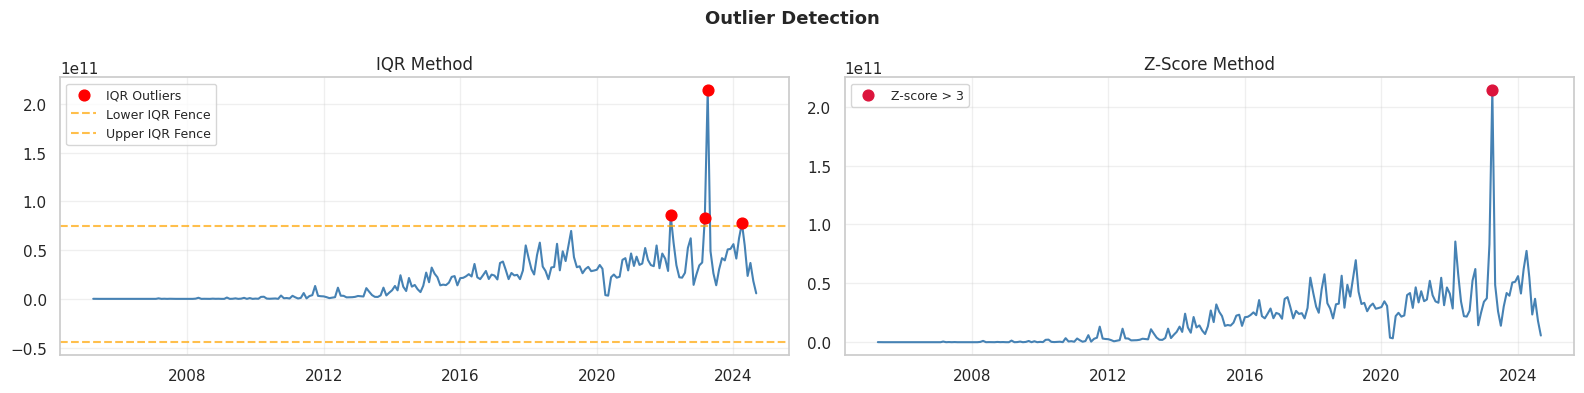


Outlier treatment: Removed impossible (non-positive) values. Legitimate high-cost projects retained.


In [ ]:
# ── Method 1: IQR-based outlier detection ────────────────────────────
Q1  = ts[TARGET_COLUMN].quantile(0.25)
Q3  = ts[TARGET_COLUMN].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers_iqr = ts[(ts[TARGET_COLUMN] < lower_iqr) | (ts[TARGET_COLUMN] > upper_iqr)]

# ── Method 2: Z-score-based outlier detection ─────────────────────────
z_scores = np.abs(stats.zscore(ts[TARGET_COLUMN].dropna()))
outliers_z = ts[TARGET_COLUMN].dropna()[z_scores > 3]

print(f"IQR method  — outliers detected: {len(outliers_iqr)}")
print(f"Z-score (>3σ) — outliers detected: {len(outliers_z)}")
print(f"\nIQR Bounds: lower={lower_iqr:.2f}, upper={upper_iqr:.2f}")

# ── Visualize outliers ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Outlier Detection', fontsize=13, fontweight='bold')

axes[0].plot(ts.index, ts[TARGET_COLUMN], color='steelblue', linewidth=1.5)
axes[0].scatter(outliers_iqr.index, outliers_iqr[TARGET_COLUMN],
                color='red', zorder=5, s=60, label='IQR Outliers')
axes[0].axhline(lower_iqr, color='orange', linestyle='--', alpha=0.7, label='Lower IQR Fence')
axes[0].axhline(upper_iqr, color='orange', linestyle='--', alpha=0.7, label='Upper IQR Fence')
axes[0].set_title('IQR Method')
axes[0].legend(fontsize=9)

axes[1].plot(ts.index, ts[TARGET_COLUMN], color='steelblue', linewidth=1.5)
axes[1].scatter(outliers_z.index, outliers_z.values,
                color='crimson', zorder=5, s=60, label='Z-score > 3')
axes[1].set_title('Z-Score Method')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# Outlier Handling: Remove impossible values only, keep legitimate high-cost projects
# Remove any non-positive values, as cost cannot be zero or negative
# ═══════════════════════════════════════════════════════════════════
ts = ts[ts[TARGET_COLUMN] > 0]

print("\nOutlier treatment: Removed impossible (non-positive) values. Legitimate high-cost projects retained.")

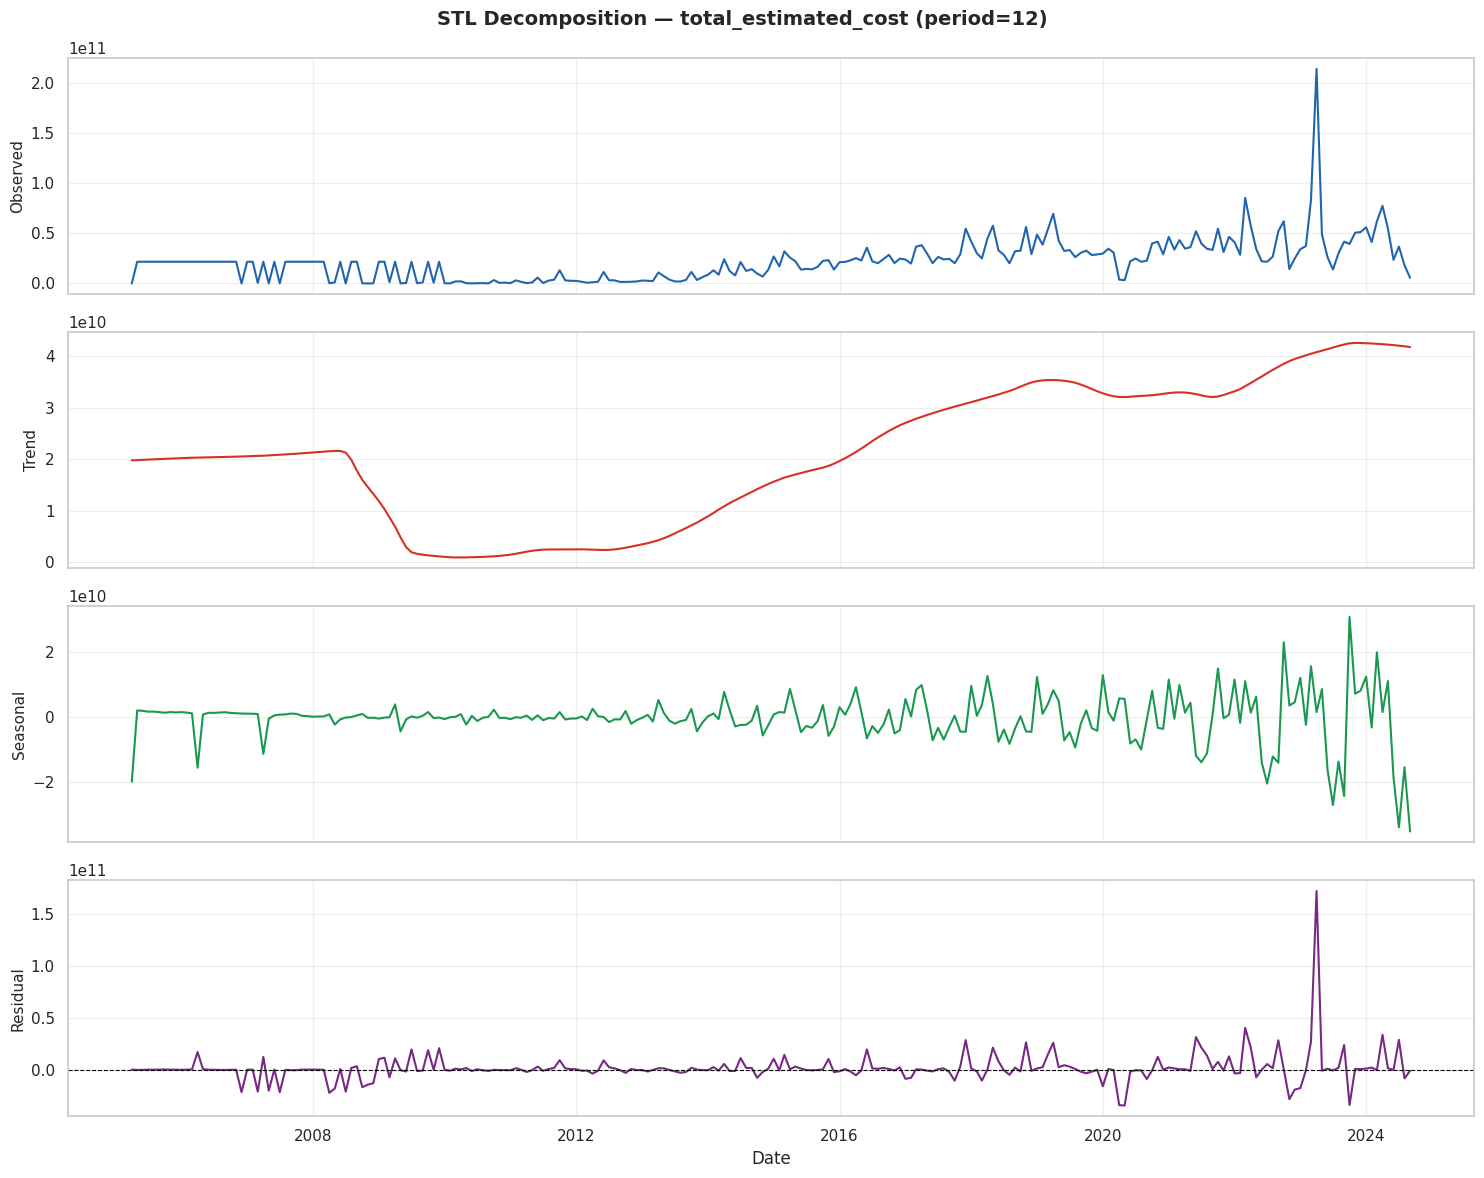

Trend Strength    : 0.4859  (0=none → 1=strong)
Seasonal Strength : 0.0885  (0=none → 1=strong)


In [ ]:
# ── Seasonal period ───────────────────────────────────────────────────
# Monthly data with annual cycle  → PERIOD = 12
PERIOD = 12

series_clean = ts[TARGET_COLUMN].asfreq(FREQ)
# Fill any NaNs that might have been introduced by .asfreq()
series_clean = series_clean.fillna(series_clean.median())

# ── STL Decomposition (robust to outliers) ────────────────────────────
stl    = STL(series_clean, period=PERIOD, robust=True)
result = stl.fit()

# ── Plot the four components ──────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fig.suptitle(f'STL Decomposition — {TARGET_COLUMN} (period={PERIOD})',
             fontsize=14, fontweight='bold')

components = [
    ('Observed',  result.observed,  '#2166ac'),
    ('Trend',     result.trend,     '#d73027'),
    ('Seasonal',  result.seasonal,  '#1a9850'),
    ('Residual',  result.resid,     '#762a83'),
]
for ax, (label, data, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=1.5)
    if label == 'Residual':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel(label, fontsize=11)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# ── Strength of trend and seasonality (0–1 scale) ────────────────────
var_resid    = np.var(result.resid)
var_trend_r  = np.var(result.trend + result.resid)
var_season_r = np.var(result.seasonal + result.resid)

trend_strength    = max(0, 1 - var_resid / var_trend_r)
seasonal_strength = max(0, 1 - var_resid / var_season_r)

print(f"Trend Strength    : {trend_strength:.4f}  (0=none → 1=strong)")
print(f"Seasonal Strength : {seasonal_strength:.4f}  (0=none → 1=strong)")

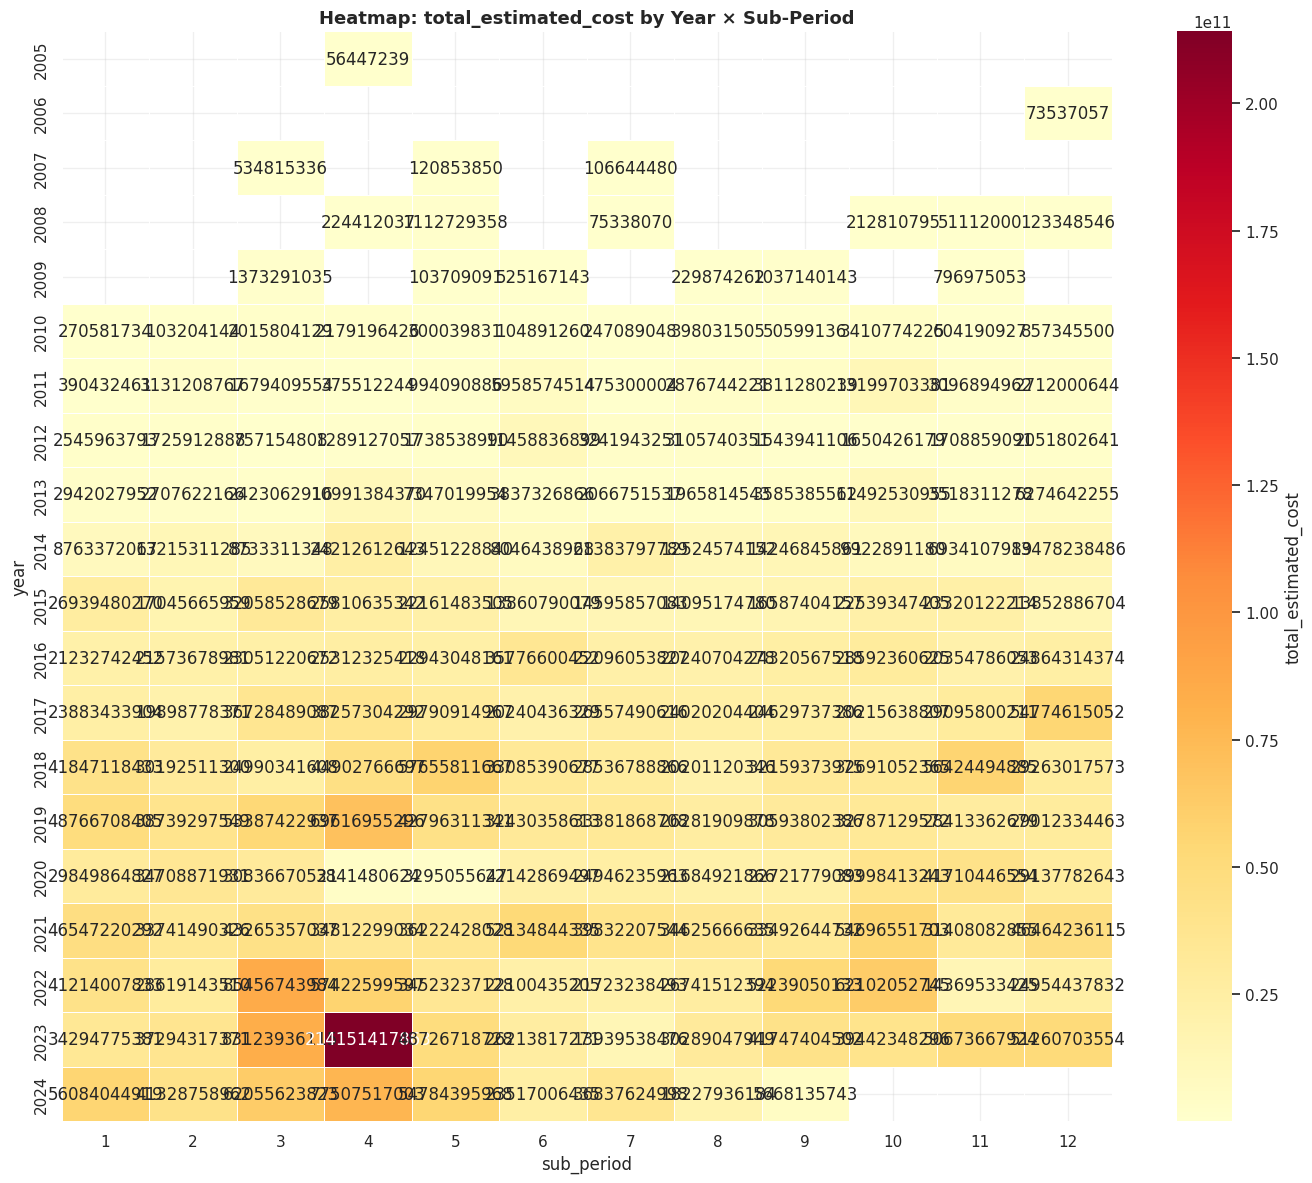

In [ ]:
# ── Heatmap: rows = Year, columns = Sub-period (e.g., month) ─────────

hm = ts.copy()
hm['year']       = hm.index.year
hm['sub_period'] = hm.index.month      # Monthly data

# Choose aggregation — 'sum' for totals
pivot = hm.pivot_table(values=TARGET_COLUMN,
                        index='year', columns='sub_period',
                        aggfunc='sum')

plt.figure(figsize=(14, max(4, len(pivot) * 0.6)))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': TARGET_COLUMN})
plt.title(f'Heatmap: {TARGET_COLUMN} by Year × Sub-Period',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

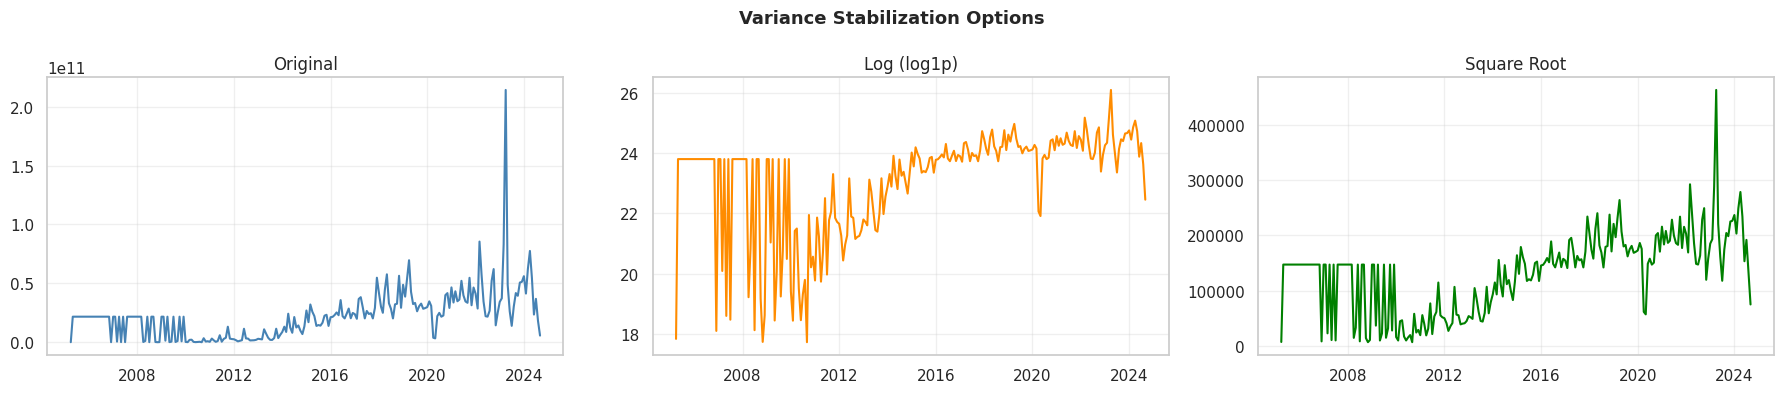

Transformation applied: True
Working series range  : [17.7394, 26.0899]


In [ ]:
# ── Check for heteroscedasticity visually ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Variance Stabilization Options', fontsize=13, fontweight='bold')

orig = series_clean.copy()

# Guard against zero/negative values for log transforms
offset = max(0, -orig.min() + 1) if orig.min() <= 0 else 0
orig_pos = orig + offset

axes[0].plot(orig,                color='steelblue',  linewidth=1.5)
axes[0].set_title('Original')

axes[1].plot(np.log1p(orig_pos),  color='darkorange', linewidth=1.5)
axes[1].set_title('Log (log1p)')

axes[2].plot(np.sqrt(orig_pos),   color='green',      linewidth=1.5)
axes[2].set_title('Square Root')

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# Apply transformation
# ═══════════════════════════════════════════════════════════════════

ts_model    = np.log1p(orig_pos) # Log transformation
ts_model = ts_model.dropna()
TRANSFORMED = True

print(f"Transformation applied: {TRANSFORMED}")
print(f"Working series range  : [{ts_model.min():.4f}, {ts_model.max():.4f}]")

In [ ]:
def adf_kpss_test(series, label='Series'):
    """Run ADF and KPSS tests and print a combined interpretation."""
    s = series.dropna()

    # ADF Test
    adf_stat, adf_p, adf_lags, adf_nobs, adf_cv, _ = adfuller(s, autolag='AIC')

    # KPSS Test
    kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression='c', nlags='auto')

    print(f"\n{'═'*60}")
    print(f"  STATIONARITY TESTS: {label}")
    print(f"{'═'*60}")
    print(f"  {'Test':<22} {'Statistic':>12} {'p-value':>10} {'Verdict':>20}")
    print(f"  {'─'*58}")

    adf_verdict  = '✅ STATIONARY'   if adf_p  < 0.05 else '❌ NON-STATIONARY'
    kpss_verdict = '✅ STATIONARY'   if kpss_p > 0.05 else '❌ NON-STATIONARY'

    print(f"  {'ADF (H0: unit root)':<22} {adf_stat:>12.4f} {adf_p:>10.4f} {adf_verdict:>20}")
    print(f"  {'KPSS (H0: stationary)':<22} {kpss_stat:>12.4f} {kpss_p:>10.4f} {kpss_verdict:>20}")

    print(f"\n  ADF Critical Values : 1%={adf_cv['1%']:.3f}  5%={adf_cv['5%']:.3f}  10%={adf_cv['10%']:.3f}")
    print(f"  KPSS Critical Values: 1%={kpss_cv['1%']:.3f}  5%={kpss_cv['5%']:.3f}  10%={kpss_cv['10%']:.3f}")

    # Consensus
    adf_stat_   = adf_p  < 0.05
    kpss_stat_  = kpss_p > 0.05
    print(f"  ┌─ CONSENSUS ───────────────────────────────────────┐")
    if adf_stat_ and kpss_stat_:
        print(f"  │  ✅ Both tests agree: STATIONARY                  │")
    elif not adf_stat_ and not kpss_stat_:
        print(f"  │  ❌ Both tests agree: NON-STATIONARY               │")
    elif adf_stat_ and not kpss_stat_:
        print(f"  │  ⚠️  Trend-stationary (possibly difference)        │")
    else:
        print(f"  │  ⚠️  Difference-stationary (possible unit root)    │")
    print(f"  └───────────────────────────────────────────────────┘")
    print(f"{'═'*60}")

    return {'adf_p': adf_p, 'kpss_p': kpss_p,
            'adf_stationary': adf_stat_, 'kpss_stationary': kpss_stat_}

print("Stationarity test function defined.")

Stationarity test function defined.


In [ ]:
# ── Test 1: Original (or transformed) series ─────────────────────────
r0 = adf_kpss_test(ts_model, label='Original / Transformed Series')

# ── Test 2: First difference ──────────────────────────────────────────
ts_diff1 = ts_model.diff(1)
r1 = adf_kpss_test(ts_diff1.dropna(), label='1st Difference (d=1)')

# ── Test 3: Seasonal difference (lag = PERIOD) ────────────────────────
ts_sdiff = ts_model.diff(PERIOD)
r_s = adf_kpss_test(ts_sdiff.dropna(), label=f'Seasonal Difference (lag={PERIOD})')

# ── Test 4: First + Seasonal difference ──────────────────────────────
ts_diff1s = ts_model.diff(PERIOD).diff(1)
r1s = adf_kpss_test(ts_diff1s.dropna(), label=f'1st + Seasonal Difference')

# ═══════════════════════════════════════════════════════════════════
# Select the stationary series
# ═══════════════════════════════════════════════════════════════════

d = 0   # Non-seasonal differences needed
D = 0   # Seasonal differences needed

# Prioritize the combined differencing if it leads to full stationarity
if r1s['adf_stationary'] and r1s['kpss_stationary']:
    d = 1
    D = 1
# Else, check if 1st Difference alone leads to full stationarity
elif r1['adf_stationary'] and r1['kpss_stationary']:
    d = 1
    D = 0
# Else, check if Seasonal Difference alone leads to full stationarity (only if PERIOD > 1)
elif PERIOD > 1 and r_s['adf_stationary'] and r_s['kpss_stationary']:
    d = 0
    D = 1
# Else, check if the Original/Transformed series is already fully stationary
elif r0['adf_stationary'] and r0['kpss_stationary']:
    d = 0
    D = 0
# If none of the above conditions lead to full stationarity by both tests,
# keep d=0, D=0 as a fallback or indicate further investigation is needed.
# In this specific case, r1s results in full stationarity.
else:
    pass

# Apply the identified differencing
if D > 0:
    ts_stationary = ts_model.diff(PERIOD)
    if d > 0:
        ts_stationary = ts_stationary.diff(d)
elif d > 0:
    ts_stationary = ts_model.diff(d)
else:
    ts_stationary = ts_model.copy()

ts_stationary = ts_stationary.dropna()

print(f"\nFinal differencing: d={d}, D={D}")
print(f"Stationary series length: {len(ts_stationary)}")


════════════════════════════════════════════════════════════
  STATIONARITY TESTS: Original / Transformed Series
════════════════════════════════════════════════════════════
  Test                      Statistic    p-value              Verdict
  ──────────────────────────────────────────────────────────
  ADF (H0: unit root)         -3.1847     0.0209         ✅ STATIONARY
  KPSS (H0: stationary)        1.6827     0.0100     ❌ NON-STATIONARY

  ADF Critical Values : 1%=-3.466  5%=-2.877  10%=-2.575
  KPSS Critical Values: 1%=0.739  5%=0.463  10%=0.347

  ┌─ CONSENSUS ───────────────────────────────────────┐
  │  ⚠️  Trend-stationary (possibly difference)        │
  └───────────────────────────────────────────────────┘
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  STATIONARITY TESTS: 1st Difference (d=1)
════════════════════════════════════════════════════════════
  Test                      Statistic    p-va

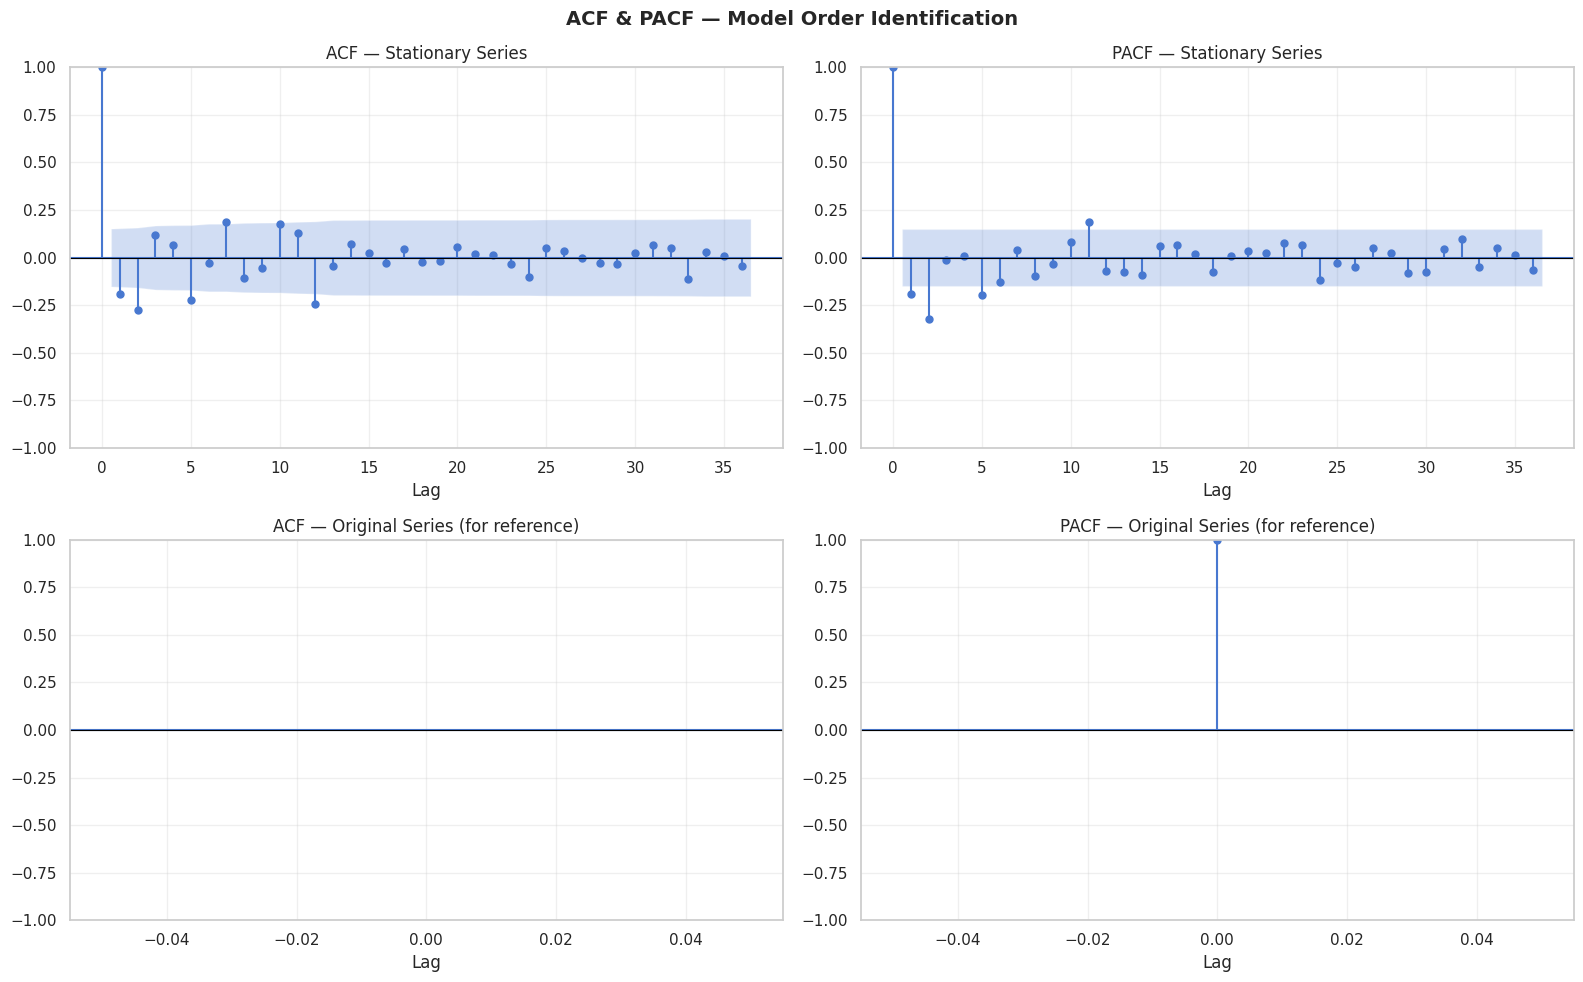


Significant lags (ACF):
Empty DataFrame
Columns: [Lag, ACF]
Index: []

Based on the ACF and PACF plots and the stationarity tests:
- ARIMA model: Suitable if seasonality is not present (D=0). Parameters (p,q) determined by significant lags in PACF/ACF of the non-seasonal differenced series.
- SARIMA model: Suitable if both trend (d>0) and seasonality (D>0, PERIOD>1) are present. Parameters (p,d,q)(P,D,Q,PERIOD) are determined from the ACF/PACF of the stationary and seasonally differenced series.
- Prophet model: Suitable for long-term forecasts with multiple seasonality patterns, holidays, and missing data. It's often easier to use for complex seasonality and non-linear trends but requires a specific input format (ds, y).

Given the presence of seasonality (PERIOD=12) and the need for seasonal differencing (D=1), a **SARIMA model** is likely the most suitable choice for this time series analysis.
Prophet could also be a robust alternative, especially if there are future plans to incor

In [ ]:
# ── ACF and PACF of the stationary series ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ACF & PACF — Model Order Identification', fontsize=14, fontweight='bold')

MAX_LAGS = min(3 * PERIOD, len(ts_stationary) // 2 - 1)

# ── Row 1: Stationary series ──────────────────────────────────────────
plot_acf( ts_stationary, lags=MAX_LAGS, ax=axes[0,0], alpha=0.05,
          title='ACF — Stationary Series')
plot_pacf(ts_stationary, lags=MAX_LAGS, ax=axes[0,1], alpha=0.05,
          method='ywm', title='PACF — Stationary Series')

# ── Row 2: Original (untransformed/undifferenced) series ─────────────
plot_acf( ts_model, lags=MAX_LAGS, ax=axes[1,0], alpha=0.05,
          title='ACF — Original Series (for reference)')
plot_pacf(ts_model, lags=MAX_LAGS, ax=axes[1,1], alpha=0.05,
          method='ywm', title='PACF — Original Series (for reference)')

for ax in axes.flat:
    ax.set_xlabel('Lag')
    ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# ── ACF / PACF value table (first 2 * PERIOD lags) ───────────────────
n_lags_table = min(2 * PERIOD, len(ts_stationary) // 2)
acf_vals  = acf( ts_stationary.dropna(), nlags=n_lags_table, alpha=0.05)
pacf_vals = pacf(ts_stationary.dropna(), nlags=n_lags_table, alpha=0.05, method='ywm')

acf_df = pd.DataFrame({
    'Lag' : range(n_lags_table + 1),
    'ACF' : acf_vals[0],
    'ACF_lower': acf_vals[1][:, 0] - acf_vals[0],
    'ACF_upper': acf_vals[1][:, 1] - acf_vals[0],
    'PACF': pacf_vals[0],
})
acf_df['ACF_sig']  = (acf_df['ACF_lower']  > 0) | (acf_df['ACF_upper'] < 0)
print("\nSignificant lags (ACF):")
print(acf_df[acf_df['ACF_sig'] & (acf_df['Lag'] > 0)][['Lag','ACF']].to_string(index=False))

print("\nBased on the ACF and PACF plots and the stationarity tests:")
print(f"- ARIMA model: Suitable if seasonality is not present (D=0). Parameters (p,q) determined by significant lags in PACF/ACF of the non-seasonal differenced series.")
print(f"- SARIMA model: Suitable if both trend (d>0) and seasonality (D>0, PERIOD>1) are present. Parameters (p,d,q)(P,D,Q,PERIOD) are determined from the ACF/PACF of the stationary and seasonally differenced series.")
print(f"- Prophet model: Suitable for long-term forecasts with multiple seasonality patterns, holidays, and missing data. It's often easier to use for complex seasonality and non-linear trends but requires a specific input format (ds, y).")

if D > 0 and PERIOD > 1:
    print(f"\nGiven the presence of seasonality (PERIOD={PERIOD}) and the need for seasonal differencing (D={D}), a **SARIMA model** is likely the most suitable choice for this time series analysis.")
elif d > 0 or not (r0['adf_stationary'] and r0['kpss_stationary']):
    print(f"\nGiven the need for non-seasonal differencing (d={d}), an **ARIMA model** (or a SARIMA with D=0) is likely the most suitable choice for this time series analysis.")
else:

    print(f"\nAs the series appears stationary without differencing (d=0, D=0), a simple ARMA model or even a **SARIMA model** with (p,0,q)(0,0,0,PERIOD) could be considered.")
print("Prophet could also be a robust alternative, especially if there are future plans to incorporate external regressors or handle complex holiday effects.")

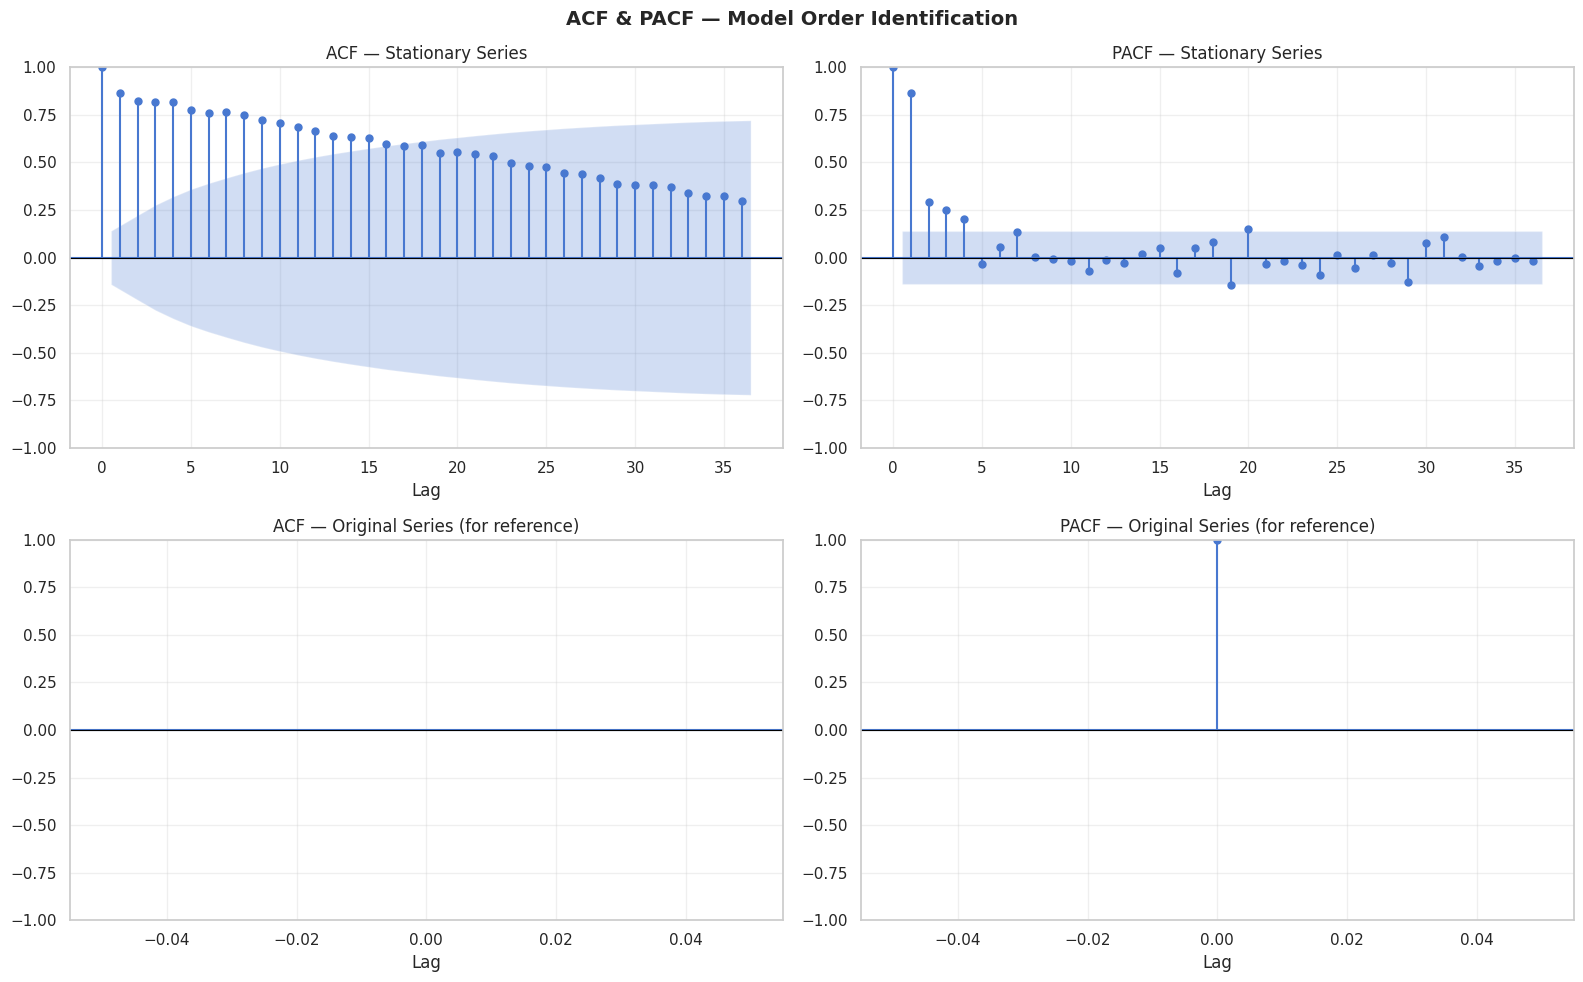


Significant lags (ACF):
Empty DataFrame
Columns: [Lag, ACF]
Index: []

Based on the ACF and PACF plots and the stationarity tests:
- ARIMA model: Suitable if seasonality is not present (D=0). Parameters (p,q) determined by significant lags in PACF/ACF of the non-seasonal differenced series.
- SARIMA model: Suitable if both trend (d>0) and seasonality (D>0, PERIOD>1) are present. Parameters (p,d,q)(P,D,Q,PERIOD) are determined from the ACF/PACF of the stationary and seasonally differenced series.
- Prophet model: Suitable for long-term forecasts with multiple seasonality patterns, holidays, and missing data. It's often easier to use for complex seasonality and non-linear trends but requires a specific input format (ds, y).

Given the need for non-seasonal differencing (d=0), an **ARIMA model** (or a SARIMA with D=0) is likely the most suitable choice for this time series analysis.
Prophet could also be a robust alternative, especially if there are future plans to incorporate external r

In [ ]:
# ── ACF and PACF of the stationary series ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ACF & PACF — Model Order Identification', fontsize=14, fontweight='bold')

MAX_LAGS = min(3 * PERIOD, len(ts_stationary) // 2 - 1)

# ── Row 1: Stationary series ──────────────────────────────────────────
plot_acf( ts_stationary, lags=MAX_LAGS, ax=axes[0,0], alpha=0.05,
          title='ACF — Stationary Series')
plot_pacf(ts_stationary, lags=MAX_LAGS, ax=axes[0,1], alpha=0.05,
          method='ywm', title='PACF — Stationary Series')

# ── Row 2: Original (untransformed/undifferenced) series ─────────────
plot_acf( ts_model, lags=MAX_LAGS, ax=axes[1,0], alpha=0.05,
          title='ACF — Original Series (for reference)')
plot_pacf(ts_model, lags=MAX_LAGS, ax=axes[1,1], alpha=0.05,
          method='ywm', title='PACF — Original Series (for reference)')

for ax in axes.flat:
    ax.set_xlabel('Lag')
    ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# ── ACF / PACF value table (first 2 * PERIOD lags) ───────────────────
n_lags_table = min(2 * PERIOD, len(ts_stationary) // 2)
acf_vals  = acf( ts_stationary.dropna(), nlags=n_lags_table, alpha=0.05)
pacf_vals = pacf(ts_stationary.dropna(), nlags=n_lags_table, alpha=0.05, method='ywm')

acf_df = pd.DataFrame({
    'Lag' : range(n_lags_table + 1),
    'ACF' : acf_vals[0],
    'ACF_lower': acf_vals[1][:, 0] - acf_vals[0],
    'ACF_upper': acf_vals[1][:, 1] - acf_vals[0],
    'PACF': pacf_vals[0],
})
acf_df['ACF_sig']  = (acf_df['ACF_lower']  > 0) | (acf_df['ACF_upper'] < 0)
print("\nSignificant lags (ACF):")
print(acf_df[acf_df['ACF_sig'] & (acf_df['Lag'] > 0)][['Lag','ACF']].to_string(index=False))

print("\nBased on the ACF and PACF plots and the stationarity tests:")
print(f"- ARIMA model: Suitable if seasonality is not present (D=0). Parameters (p,q) determined by significant lags in PACF/ACF of the non-seasonal differenced series.")
print(f"- SARIMA model: Suitable if both trend (d>0) and seasonality (D>0, PERIOD>1) are present. Parameters (p,d,q)(P,D,Q,PERIOD) are determined from the ACF/PACF of the stationary and seasonally differenced series.")
print(f"- Prophet model: Suitable for long-term forecasts with multiple seasonality patterns, holidays, and missing data. It's often easier to use for complex seasonality and non-linear trends but requires a specific input format (ds, y).")

if D > 0 and PERIOD > 1:
    print(f"\nGiven the presence of seasonality (PERIOD={PERIOD}) and the need for seasonal differencing (D={D}), a **SARIMA model** is likely the most suitable choice for this time series analysis.")
elif d > 0 or not (r0['adf_stationary'] and r0['kpss_stationary']):
    print(f"\nGiven the need for non-seasonal differencing (d={d}), an **ARIMA model** (or a SARIMA with D=0) is likely the most suitable choice for this time series analysis.")
else:
    print(f"\nAs the series appears stationary without differencing (d=0, D=0), a simple ARMA model or even a **SARIMA model** with (p,0,q)(0,0,0,PERIOD) could be considered.")
print("Prophet could also be a robust alternative, especially if there are future plans to incorporate external regressors or handle complex holiday effects.")

# Phase 4 - Modeling

## Classification Model

In [ ]:
cls_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100,
                                                   max_depth=10,
                                                   random_state=42,
                                                   class_weight='balanced'),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100,
                                                       max_depth=5,
                                                       random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
}

cls_results = {}

for name, model in cls_models.items():
    model.fit(X_train_cls_sc, y_train_cls)
    y_pred = model.predict(X_test_cls_sc)
    y_prob = model.predict_proba(X_test_cls_sc)[:,1] if hasattr(model, 'predict_proba') else None

    cls_results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test_cls, y_pred),
        'precision': precision_score(y_test_cls, y_pred, zero_division=0),
        'recall'   : recall_score(y_test_cls, y_pred, zero_division=0),
        'f1'       : f1_score(y_test_cls, y_pred, zero_division=0),
        'roc_auc'  : roc_auc_score(y_test_cls, y_prob) if y_prob is not None else np.nan,
    }
    print(f"[{name}] Acc={cls_results[name]['accuracy']:.3f} | "
          f"F1={cls_results[name]['f1']:.3f} | "
          f"AUC={cls_results[name]['roc_auc']:.3f} | "
          f"Precision={cls_results[name]['precision']:.3f} | "
          f"Recall={cls_results[name]['recall']:.3f}")

best_cls_name = max(cls_results, key=lambda k: cls_results[k]['f1'])
print(f"\n✅ Best classifier (F1): {best_cls_name}")
best_cls_model = cls_results[best_cls_name]['model']

## Clustering Model

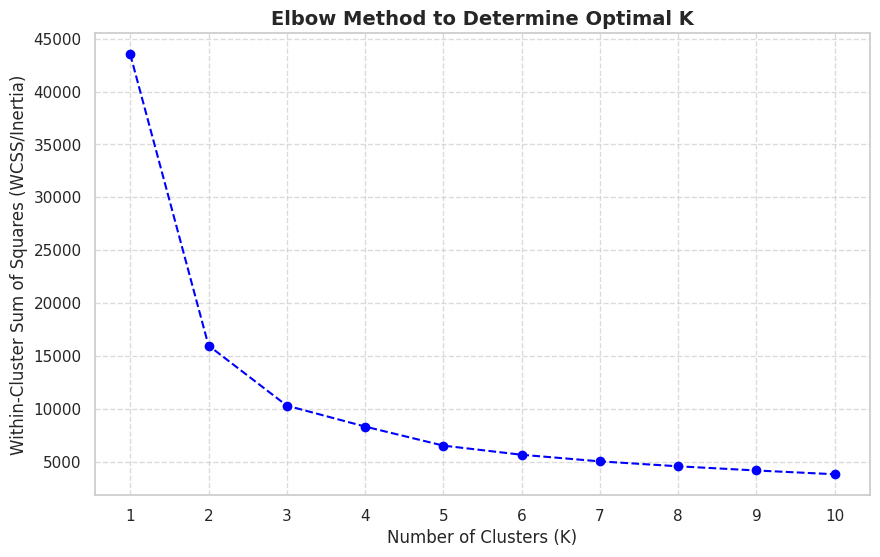

In [ ]:
# ====================================================
# CLUSTERING MODEL - ELBOW METHOD
# ====================================================
wcss = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method to Determine Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS/Inertia)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# ====================================================
# CLUSTERING MODEL - K MEANS
# ====================================================

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Generate cluster labels
cluster_labels = kmeans.fit_predict(scaled_df)

# Attach cluster labels back to original data
df_clustered = df_transformed.loc[actual_indices_used_for_clustering].copy()
df_clustered['cluster_label'] = cluster_labels

print(f"K-Means clustering applied with K={k}.")
print("Cluster labels added to 'df_clustered'.")

print("\nCluster distribution:")
display(df_clustered['cluster_label'].value_counts().sort_index())

print("\nSample Data:")
display(df_clustered.head())

K-Means clustering applied with K=3.
Cluster labels added to 'df_clustered'.

Cluster distribution:


,count
cluster_label,
0,8088
1,2253
2,4166



Sample Data:


,project_reg_id,project_name,promoter_name,project_type,promoter_type,project_address,project_address2,under_redevelopment,dist_name,tpo_code,...,project_duration_days,booked_units_ratio,selling_amount_ratio,cost_overrun_ratio,delay_risk,log_total_estimated_cost,log_total_incurred_cost,log_total_units,log_total_land_cost,cluster_label
0,7871,SURAT DIAMOND BOURSE,SDB DIAMOND BOURSE,Commercial,COMPANY,"BLOCK NO.177, VILLAGE KHAJOD, TALUKA MAJURA",SURAT,NO,Surat,SUDA,...,2033.0,0.904752,0.852416,1.0,1,24.044677,24.044677,8.476163,22.622450,1
1,1109,GLOBALE TEXTILE MARKET,GLOBALE INFRASPACE LLP,Commercial,LIMITED LIABILITY PARTNERSHIP FIRM,GLOBALE TEXTILE MARKET,"UMARWADA, KADODARA ROAD, SURAT",NO,Surat,SURAT TPO,...,1988.0,0.514917,0.521757,1.0,1,22.684768,22.684768,8.230844,22.020729,1
2,4258,68 SHOPS + 1228 LIG-2 + 432 MIG-1 AT GOTA,GUJARAT HOUSING BOARD,Mixed Development,COMPETENT AUTHORITY/ GOVERNMENT,VASANTNAGAR TOWNSHIP,"GOTA OGNAJ ROAD, GOTA",NO,Ahmedabad,AUDA,...,1566.0,0.957755,0.982992,1.0,0,21.439013,21.439013,8.148156,14.652322,1
3,5212,SHREE KUBERJI VALENTINE TEXTILE MARKET,SHREE KUBERJI BUILDCON,Commercial,PARTNERSHIP FIRM,"BLOCK NO:258-259,TP:35,SAROLI-KUMBHARIYA","OPP.BHARAT CANCER HOSPITAL,SURAT KADODARA ROAD",NO,Surat,SUDA,...,2403.0,0.214375,0.216543,1.0,1,21.618710,21.618710,8.071219,19.749298,1
4,10965,Construction of EWS - I and EWS-II (2560 HOUS...,SURAT URBAN DEVELOPMENT AUTHORITY,Residential/Group Housing,COMPETENT AUTHORITY/ GOVERNMENT,TP SCHEME NO 30 AT VANAKLA,FINAL PLOT NUMBER 129,NO,Surat,SUDA,...,1552.0,0.000000,0.000000,1.0,0,21.596231,21.596231,7.848153,0.000000,1


## Time Series Model

Training : 2005-04-01 → 2023-09-01  (222 periods)
Test     : 2023-10-01  → 2024-09-01  (12 periods)
Split    : 94.9% train / 5.1% test


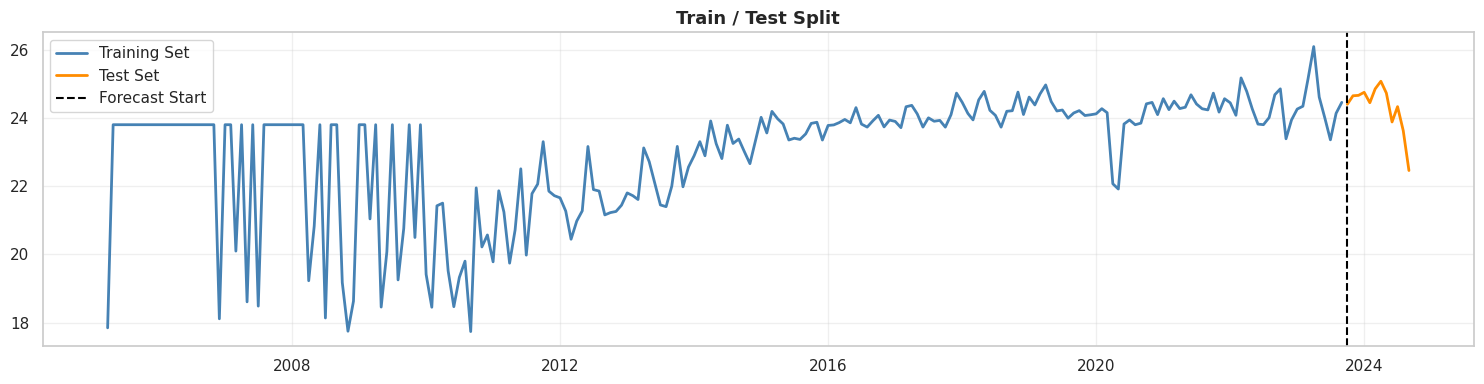

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Define forecast horizon and split the series
# ═══════════════════════════════════════════════════════════════════

FORECAST_HORIZON = PERIOD

train = ts_model.iloc[:-FORECAST_HORIZON]
test  = ts_model.iloc[-FORECAST_HORIZON:]

print(f"Training : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} periods)")
print(f"Test     : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} periods)")
print(f"Split    : {len(train)/len(ts_model)*100:.1f}% train / {len(test)/len(ts_model)*100:.1f}% test")

plt.figure(figsize=(15, 4))
plt.plot(train, color='steelblue', linewidth=2, label='Training Set')
plt.plot(test,  color='darkorange', linewidth=2, label='Test Set')
plt.axvline(x=test.index[0], color='black', linestyle='--', linewidth=1.5, label='Forecast Start')
plt.title('Train / Test Split', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pmdarima as pm

# Define the ranges for p, d, q, P, D, Q
p_range = range(0, 4)  # Expanded Non-seasonal AR order
q_range = range(0, 4)  # Expanded Non-seasonal MA order

P_range_expanded = range(0, 4)  # Expanded Seasonal AR order
Q_range_expanded = range(0, 4)  # Expanded Seasonal MA order
s = PERIOD              # Seasonal period (from previous analysis)

print(f"Searching for optimal SARIMA({p_range}, {d}, {q_range})({P_range_expanded}, {D}, {Q_range_expanded}, {s}) orders...")

# Ensure train series is completely free of NaNs before passing to auto_arima
train_clean = train.dropna()

# Fit auto_arima to the training data
# We set suppress_warnings=True to avoid printing too many convergence warnings
optimized_sarima_model = pm.auto_arima(train_clean,
                                       start_p=min(p_range),
                                       max_p=max(p_range),
                                       start_q=min(q_range),
                                       max_q=max(q_range),
                                       d=d, # Use the previously determined non-seasonal differencing
                                       max_d=2, # Allowing up to 2 differencing terms for safety
                                       start_P=min(P_range_expanded),
                                       max_P=max(P_range_expanded),
                                       start_Q=min(Q_range_expanded),
                                       max_Q=max(Q_range_expanded),
                                       D=D, # Use the previously determined seasonal differencing
                                       max_D=1, # Allowing up to 1 seasonal differencing term for safety
                                       m=s,
                                       seasonal=True,
                                       stepwise=True, # Use stepwise search for efficiency
                                       suppress_warnings=True,
                                       error_action='ignore',
                                       trace=True,
                                       random_state=42,
                                       n_fits=50) # Number of models to fit

print("\nOptimal SARIMA parameters found by auto_arima:")
print(optimized_sarima_model.summary())

# Extract the best parameters
best_order = optimized_sarima_model.order
best_seasonal_order = optimized_sarima_model.seasonal_order

print(f"\n✅ Optimal (p,d,q) order: {best_order}")
print(f"✅ Optimal (P,D,Q,s) seasonal order: {best_seasonal_order}")

Searching for optimal SARIMA(range(0, 4), 1, range(0, 4))(range(0, 4), 1, range(0, 4), 12) orders...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=967.110, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=864.643, Time=0.16 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.23 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=915.536, Time=0.05 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=835.722, Time=0.37 sec
 ARIMA(1,1,0)(3,1,0)[12]             : AIC=814.235, Time=0.79 sec
 ARIMA(1,1,0)(3,1,1)[12]             : AIC=797.570, Time=2.87 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.84 sec
 ARIMA(1,1,0)(3,1,2)[12]             : AIC=799.196, Time=8.02 sec
 ARIMA(1,1,0)(2,1,2)[12]             : AIC=797.201, Time=2.96 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=inf, Time=2.17 sec
 ARIMA(1,1,0)(2,1,3)[12]             : AIC=799.184, Time=8.14 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.03 sec
 ARIMA(1,1,0)(

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Fill in the final selected order parameters
# Use the best model from the auto_arima search above
# ═══════════════════════════════════════════════════════════════════

BEST_ORDER          = best_order       # (p, d, q) from auto_arima
BEST_SEASONAL_ORDER = best_seasonal_order  # (P, D, Q, s) from auto_arima

final_model = SARIMAX(
    train,
    order=BEST_ORDER,
    seasonal_order=BEST_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_result = final_model.fit(disp=False)

print(final_result.summary())

                                         SARIMAX Results                                          
Dep. Variable:                       total_estimated_cost   No. Observations:                  222
Model:             SARIMAX(2, 1, 0)x(0, 1, [1, 2, 3], 12)   Log Likelihood                -282.232
Date:                                    Tue, 12 May 2026   AIC                            576.464
Time:                                            20:08:05   BIC                            595.349
Sample:                                        04-01-2005   HQIC                           584.127
                                             - 09-01-2023                                         
Covariance Type:                                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6225      0.037    -16.942      0

In [ ]:
# ── Extract and display key model statistics ──────────────────────────
print("=" * 55)
print(" KEY MODEL DIAGNOSTICS FROM SUMMARY")
print("=" * 55)
print(f"  Model AIC  : {final_result.aic:.3f}")
print(f"  Model BIC  : {final_result.bic:.3f}")
print(f"  Model HQIC : {final_result.hqic:.3f}")
print(f"  Log-Likelihood: {final_result.llf:.3f}")

print("\n  Coefficient p-values:")
coef_df = pd.DataFrame({
    'Coefficient': final_result.params,
    'Std Error'  : final_result.bse,
    'z-stat'     : final_result.tvalues,
    'p-value'    : final_result.pvalues
})
coef_df['Significant'] = coef_df['p-value'].apply(lambda x: '✅' if x < 0.05 else '⚠️  Not sig.')
print(coef_df.round(4).to_string())

 KEY MODEL DIAGNOSTICS FROM SUMMARY
  Model AIC  : 576.464
  Model BIC  : 595.349
  Model HQIC : 584.127
  Log-Likelihood: -282.232

  Coefficient p-values:
          Coefficient  Std Error   z-stat  p-value   Significant
ar.L1         -0.6225     0.0367 -16.9424   0.0000             ✅
ar.L2         -0.3890     0.0422  -9.2148   0.0000             ✅
ma.S.L12      -0.7778     0.0727 -10.7047   0.0000             ✅
ma.S.L24      -0.0962     0.0698  -1.3786   0.1680  ⚠️  Not sig.
ma.S.L36       0.1643     0.0794   2.0700   0.0385             ✅
sigma2         1.5136     0.1208  12.5313   0.0000             ✅


# Phase 5 - Evaluation

## Classification Evaluation

In [ ]:
# ====================================================
# CLASSIFICATION EVALUATION - Decision Tree
# ====================================================

print("=" * 55)
print(" DECISION TREE CLASSIFIER EVALUATION")
print("=" * 55)

# Calculate metrics
accuracy = accuracy_score(y_test_cls, y_pred)
precision = precision_score(y_test_cls, y_pred, zero_division=0)
recall = recall_score(y_test_cls, y_pred, zero_division=0)
f1 = f1_score(y_test_cls, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test_cls, y_prob)

print(f"\nPerformance Metrics:")
print(f"  Accuracy  : {accuracy:.3f}")
print(f"  Precision : {precision:.3f}")
print(f"  Recall    : {recall:.3f}")
print(f"  F1 Score  : {f1:.3f}")
print(f"  ROC-AUC   : {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred,
                             target_names=['Not at Risk', 'At Risk (Delay)']))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_cls, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not at Risk', 'At Risk'],
            yticklabels=['Not at Risk', 'At Risk'],
            annot_kws={'size': 14})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)

# Feature Importance
feature_importance = pd.Series(best_cls_model.feature_importances_,
                               index=X_train_cls.columns).sort_values(ascending=True)

colors = ['steelblue' if v > 0 else 'lightgray' for v in feature_importance.values]
feature_importance.plot(kind='barh', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Decision Tree Feature Importances', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Importance Score')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Print top features
print("\nFeature Importances:")
for feature, importance in feature_importance.sort_values(ascending=False).items():
    print(f"  {feature}: {importance:.4f}")

## Clustering Evaluation

Silhouette Score: 0.4992
Davies-Bouldin Index: 0.8353


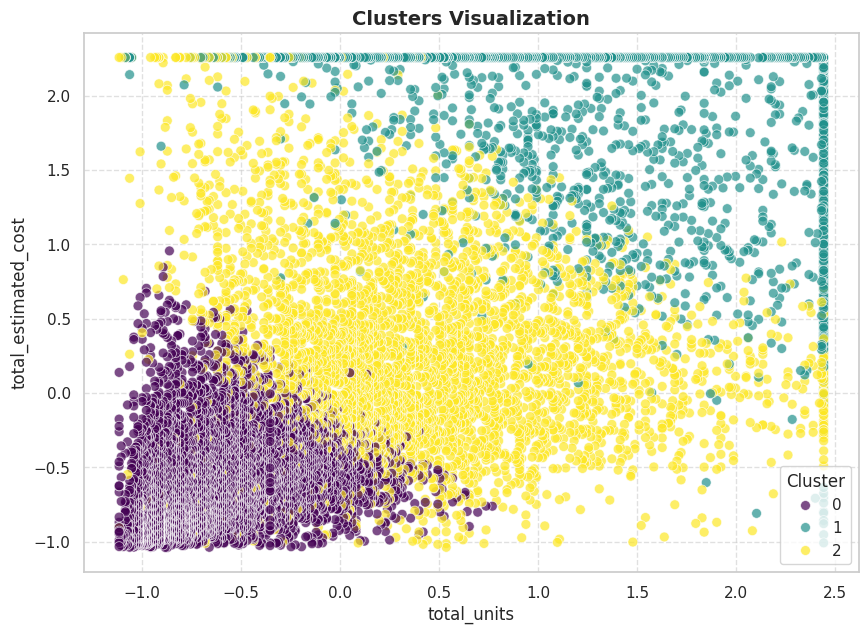

In [ ]:
# ====================================================
# CLUSTERING EVALUATION
# ====================================================

# Silhouette Score (higher = better separation)
if len(np.unique(cluster_labels)) > 1:
    silhouette_avg = silhouette_score(scaled_df, cluster_labels)
    print(f"Silhouette Score: {silhouette_avg:.4f}")
else:
    print("Silhouette Score not applicable.")

# Davies-Bouldin Index (lower = better clustering)
dbi_score = davies_bouldin_score(scaled_df, cluster_labels)
print(f"Davies-Bouldin Index: {dbi_score:.4f}")

# Visualize clusters using first two scaled features
x_col = scaled_df.columns[0]
y_col = scaled_df.columns[1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=scaled_df[x_col],
    y=scaled_df[y_col],
    hue=cluster_labels,
    palette='viridis',
    s=50,
    alpha=0.7
)
plt.title('Clusters Visualization', fontsize=14, fontweight='bold')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Time Series Evaluation

In [ ]:
# ── Generate forecast over the test horizon ───────────────────────────
forecast_obj  = final_result.get_forecast(steps=FORECAST_HORIZON)
forecast_mean = forecast_obj.predicted_mean
conf_int      = forecast_obj.conf_int(alpha=0.05)   # 95% CI

# ── Align index ──────────────────────────────────────────────────────
forecast_mean.index = test.index
conf_int.index      = test.index
lower_ci = conf_int.iloc[:, 0]
upper_ci = conf_int.iloc[:, 1]

# ═══════════════════════════════════════════════════════════════════
# Back-transform the forecast to the original scale
# ═══════════════════════════════════════════════════════════════════
if TRANSFORMED:
    # For log1p: back-transform = expm1()
    # For sqrt : back-transform = square()
    forecast_mean = np.expm1(forecast_mean)          # apply inverse transform
    lower_ci      = np.expm1(lower_ci)
    upper_ci      = np.expm1(upper_ci)
    test_actual   = np.expm1(test)          # also back-transform test set
else:
    test_actual = test.copy()

# ── Summary table ─────────────────────────────────────────────────────
forecast_summary = pd.DataFrame({
    'Actual'      : test_actual,
    'Forecast'    : forecast_mean.values,
    'Lower 95% CI': lower_ci.values,
    'Upper 95% CI': upper_ci.values,
})
forecast_summary['Within CI'] = (
    (forecast_summary['Actual'] >= forecast_summary['Lower 95% CI']) &
    (forecast_summary['Actual'] <= forecast_summary['Upper 95% CI'])
)
print(forecast_summary.round(3).to_string())
pct_within = forecast_summary['Within CI'].mean() * 100
print(f"\n{pct_within:.1f}% of actual values fall within the 95% confidence interval.")

                  Actual      Forecast  Lower 95% CI  Upper 95% CI  Within CI
2023-10-01  3.944235e+10  3.530639e+10  3.166980e+09  3.936056e+11       True
2023-11-01  5.067367e+10  3.303578e+10  2.509780e+09  4.348442e+11       True
2023-12-01  5.126070e+10  3.439389e+10  2.238206e+09  5.285214e+11       True
2024-01-01  5.608404e+10  4.020998e+10  1.787268e+09  9.046448e+11       True
2024-02-01  4.132876e+10  3.694548e+10  1.346506e+09  1.013711e+12       True
2024-03-01  6.205562e+10  5.377036e+10  1.625978e+09  1.778162e+12       True
2024-04-01  7.750752e+10  4.656477e+10  1.126182e+09  1.925336e+12       True
2024-05-01  5.478440e+10  3.042796e+10  6.127214e+08  1.511063e+12       True
2024-06-01  2.351701e+10  3.413618e+10  5.771583e+08  2.018993e+12       True
2024-07-01  3.683762e+10  2.833096e+10  4.011542e+08  2.000835e+12       True
2024-08-01  1.822794e+10  3.004402e+10  3.608964e+08  2.501114e+12       True
2024-09-01  5.668136e+09  3.635884e+10  3.727313e+08  3.546698e+

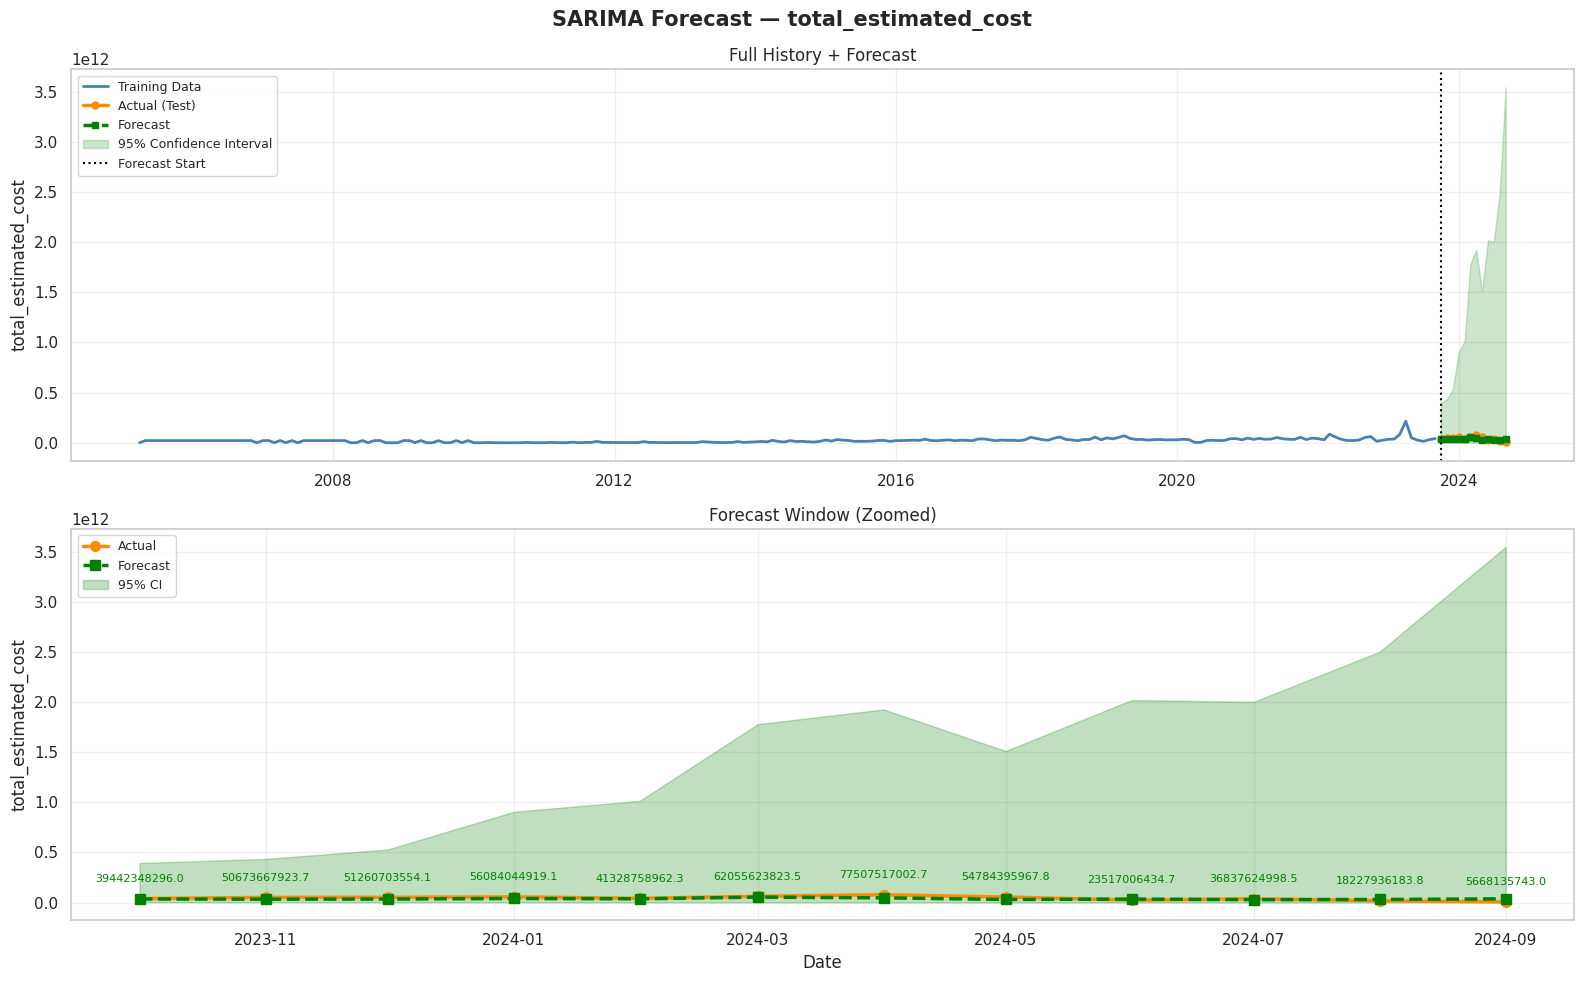

In [ ]:
# ── Back-transform training series if needed ──────────────────────────
if TRANSFORMED:
    train_plot = np.expm1(train)   # back-transform train
else:
    train_plot = train.copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(f'SARIMA Forecast — {TARGET_COLUMN}', fontsize=15, fontweight='bold')

# ── Full history + forecast ───────────────────────────────────────────
axes[0].plot(train_plot, color='steelblue', linewidth=2, label='Training Data')
axes[0].plot(test_actual, color='darkorange', linewidth=2.5,
             marker='o', markersize=5, label='Actual (Test)')
axes[0].plot(forecast_mean, color='green', linewidth=2.5,
             linestyle='--', marker='s', markersize=5, label='Forecast')
axes[0].fill_between(test.index, lower_ci, upper_ci,
                     alpha=0.2, color='green', label='95% Confidence Interval')
axes[0].axvline(x=test.index[0], color='black', linestyle=':',
                linewidth=1.5, label='Forecast Start')
axes[0].set_title('Full History + Forecast')
axes[0].set_ylabel(TARGET_COLUMN)
axes[0].legend(loc='upper left', fontsize=9)

# ── Zoomed forecast window ────────────────────────────────────────────
axes[1].plot(test_actual, color='darkorange', linewidth=2.5,
             marker='o', markersize=7, label='Actual')
axes[1].plot(forecast_mean, color='green', linewidth=2.5,
             linestyle='--', marker='s', markersize=7, label='Forecast')
axes[1].fill_between(test.index, lower_ci, upper_ci,
                     alpha=0.25, color='green', label='95% CI')
for i, (idx, row) in enumerate(forecast_summary.iterrows()):
    color = 'green' if row['Within CI'] else 'red'
    axes[1].annotate(f"{row['Actual']:.1f}",
                     xy=(idx, row['Actual']),
                     xytext=(0, 12), textcoords='offset points',
                     ha='center', fontsize=8, color=color)
axes[1].set_title('Forecast Window (Zoomed)')
axes[1].set_ylabel(TARGET_COLUMN)
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ── Helper: custom metrics ─────────────────────────────────────────────
def smape(actual, forecast):
    """Symmetric Mean Absolute Percentage Error (0–200%)."""
    return 100 * np.mean(2 * np.abs(actual - forecast) /
                         (np.abs(actual) + np.abs(forecast) + 1e-9))

def mape(actual, forecast):
    """Mean Absolute Percentage Error."""
    return 100 * np.mean(np.abs((actual - forecast) / (actual + 1e-9)))

# ── Compute metrics ───────────────────────────────────────────────────
actual_vals   = test_actual.values
forecast_vals = forecast_mean.values

mae_val   = mean_absolute_error(actual_vals, forecast_vals)
rmse_val  = np.sqrt(mean_squared_error(actual_vals, forecast_vals))
mape_val  = mape(actual_vals, forecast_vals)
smape_val = smape(actual_vals, forecast_vals)

# ── Naïve baseline: last observed value repeated ─────────────────────
naive_forecast = np.full(FORECAST_HORIZON, train_plot.iloc[-1])
mae_naive  = mean_absolute_error(actual_vals, naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(actual_vals, naive_forecast))

# ── Seasonal naïve: repeat same period from last cycle ───────────────
seasonal_naive = train_plot.values[-PERIOD:] if len(train_plot) >= PERIOD else naive_forecast
seasonal_naive = np.tile(seasonal_naive, int(np.ceil(FORECAST_HORIZON / PERIOD)))[:FORECAST_HORIZON]
mae_snaive  = mean_absolute_error(actual_vals, seasonal_naive)
rmse_snaive = np.sqrt(mean_squared_error(actual_vals, seasonal_naive))

# ── Print comparison table ────────────────────────────────────────────
metrics_df = pd.DataFrame({
    'Model'  : ['SARIMA (Your Model)', 'Naïve Baseline', 'Seasonal Naïve'],
    'MAE'    : [mae_val, mae_naive, mae_snaive],
    'RMSE'   : [rmse_val, rmse_naive, rmse_snaive],
    'MAPE %' : [mape_val, mape(actual_vals, naive_forecast),
                mape(actual_vals, seasonal_naive)],
    'SMAPE %': [smape_val, smape(actual_vals, naive_forecast),
                smape(actual_vals, seasonal_naive)]
})
metrics_df = metrics_df.round(4)
print("\n" + "=" * 72)
print(" MODEL PERFORMANCE COMPARISON")
print("=" * 72)
print(metrics_df.to_string(index=False))
print("=" * 72)
print("\n📌 Lower values = better performance for all metrics.")
print("   MAPE > 100% or SMAPE > 100% indicates very poor fit.")

# ── Skill score (vs naïve): how much better than random? ─────────────
skill_mae  = 1 - mae_val  / mae_naive
skill_rmse = 1 - rmse_val / rmse_naive
print(f"\n  Skill Score (vs Naïve) — MAE : {skill_mae*100:.1f}% improvement")
print(f"  Skill Score (vs Naïve) — RMSE: {skill_rmse*100:.1f}% improvement")


 MODEL PERFORMANCE COMPARISON
              Model          MAE         RMSE   MAPE %  SMAPE %
SARIMA (Your Model) 1.534292e+10 1.772450e+10  74.1143  43.0054
     Naïve Baseline 1.561201e+10 1.926507e+10  85.6383  41.7380
     Seasonal Naïve 2.904992e+10 4.485665e+10 102.2211  60.0951

📌 Lower values = better performance for all metrics.
   MAPE > 100% or SMAPE > 100% indicates very poor fit.

  Skill Score (vs Naïve) — MAE : 1.7% improvement
  Skill Score (vs Naïve) — RMSE: 8.0% improvement


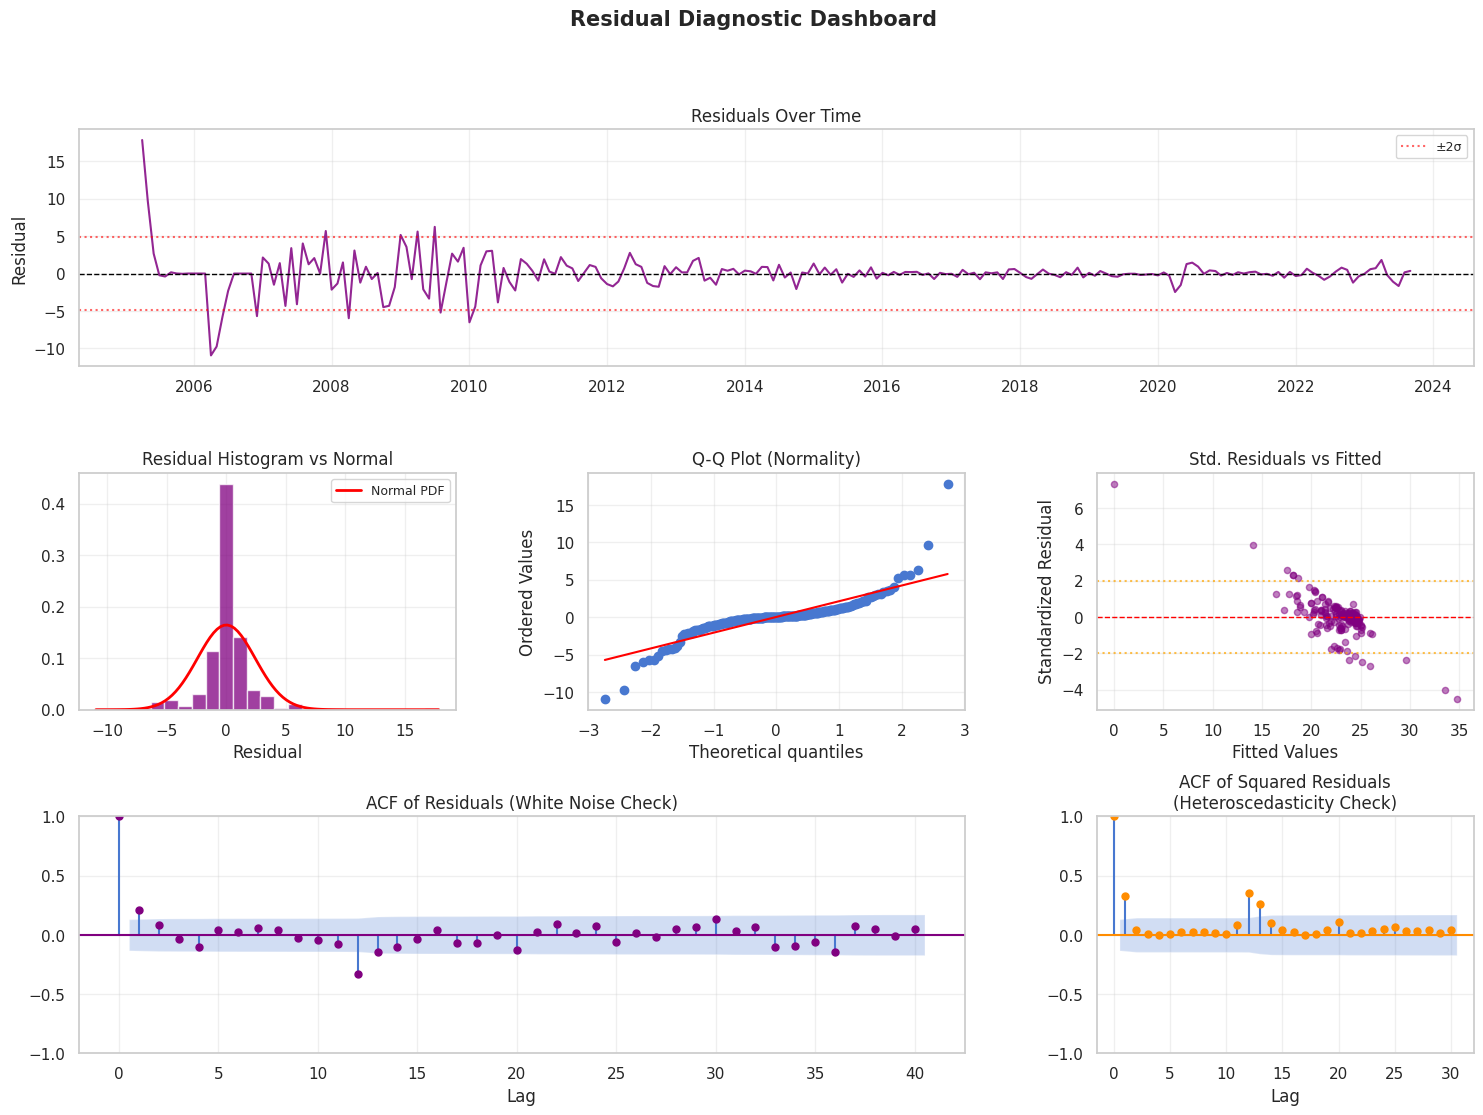

In [ ]:
# ── Extract residuals ─────────────────────────────────────────────────
residuals = final_result.resid

# ═══════════════════════════════════════════════════════════════════
# RESIDUAL DIAGNOSTIC DASHBOARD
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Residual Diagnostic Dashboard', fontsize=15, fontweight='bold')

# ── Plot 1: Residuals over time ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuals, color='purple', linewidth=1.5, alpha=0.85)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.axhline( 2 * residuals.std(), color='red', linestyle=':', alpha=0.6, label='±2σ')
ax1.axhline(-2 * residuals.std(), color='red', linestyle=':', alpha=0.6)
ax1.set_title('Residuals Over Time')
ax1.set_ylabel('Residual')
ax1.legend(fontsize=9)

# ── Plot 2: Residual histogram ────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals, bins=25, color='purple', edgecolor='white', alpha=0.75, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
ax2.plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
         color='red', linewidth=2, label='Normal PDF')
ax2.set_title('Residual Histogram vs Normal')
ax2.set_xlabel('Residual')
ax2.legend(fontsize=9)

# ── Plot 3: Q-Q Plot (normality check) ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
stats.probplot(residuals.dropna(), dist='norm', plot=ax3)
ax3.set_title('Q-Q Plot (Normality)')
ax3.get_lines()[1].set_color('red')

# ── Plot 4: Standardized residuals vs fitted ──────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
std_resid = (residuals - residuals.mean()) / residuals.std()
ax4.scatter(final_result.fittedvalues, std_resid, alpha=0.5, color='purple', s=20)
ax4.axhline(0, color='red', linestyle='--', linewidth=1)
ax4.axhline( 2, color='orange', linestyle=':', alpha=0.7)
ax4.axhline(-2, color='orange', linestyle=':', alpha=0.7)
ax4.set_title('Std. Residuals vs Fitted')
ax4.set_xlabel('Fitted Values')
ax4.set_ylabel('Standardized Residual')

# ── Plot 5: ACF of residuals (should be white noise) ──────────────────
ax5 = fig.add_subplot(gs[2, 0:2])
plot_acf(residuals.dropna(), lags=min(40, len(residuals)//2-1),
         ax=ax5, alpha=0.05, color='purple')
ax5.set_title('ACF of Residuals (White Noise Check)')
ax5.set_xlabel('Lag')

# ── Plot 6: Squared residuals ACF (volatility clustering check) ───────
ax6 = fig.add_subplot(gs[2, 2])
plot_acf(residuals.dropna()**2, lags=min(30, len(residuals)//2-1),
         ax=ax6, alpha=0.05, color='darkorange')
ax6.set_title('ACF of Squared Residuals\n(Heteroscedasticity Check)')
ax6.set_xlabel('Lag')

plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# FORMAL STATISTICAL TESTS ON RESIDUALS
# ═══════════════════════════════════════════════════════════════════

print("=" * 60)
print(" FORMAL RESIDUAL TESTS")
print("=" * 60)

# ── Test 1: Ljung-Box (autocorrelation in residuals) ─────────────────
lb_result = acorr_ljungbox(residuals.dropna(),
                           lags=[PERIOD, 2*PERIOD], return_df=True)
print("\n1. Ljung-Box Test (H0: No autocorrelation in residuals)")
print(lb_result)
for _, row in lb_result.iterrows():
    verdict = "✅ White noise" if row['lb_pvalue'] > 0.05 else "⚠️  Autocorrelation present"
    print(f"   Lag {int(row.name):>3}: p={row['lb_pvalue']:.4f} → {verdict}")

# ── Test 2: Shapiro-Wilk (normality of residuals) ────────────────────
# Use first 5000 observations (Shapiro-Wilk limit)
sw_sample = residuals.dropna().values[:5000]
sw_stat, sw_p = shapiro(sw_sample)
sw_verdict = "✅ Normal" if sw_p > 0.05 else "⚠️  Non-normal"
print(f"\n2. Shapiro-Wilk Test (H0: Residuals are normal)")
print(f"   Statistic={sw_stat:.4f}, p-value={sw_p:.4f} → {sw_verdict}")

# ── Test 3: D'Agostino-Pearson (normality, for larger samples) ───────
dp_stat, dp_p = normaltest(residuals.dropna().values)
dp_verdict = "✅ Normal" if dp_p > 0.05 else "⚠️  Non-normal"
print(f"\n3. D'Agostino-Pearson Test (H0: Residuals are normal)")
print(f"   Statistic={dp_stat:.4f}, p-value={dp_p:.4f} → {dp_verdict}")

# ── Residual summary statistics ───────────────────────────────────────
print(f"\n4. Residual Summary")
print(f"   Mean     : {residuals.mean():.6f}  (should be ≈ 0)")
print(f"   Std Dev  : {residuals.std():.4f}")
print(f"   Skewness : {residuals.skew():.4f}  (should be ≈ 0)")
print(f"   Kurtosis : {residuals.kurt():.4f}  (excess; should be ≈ 0)")

 FORMAL RESIDUAL TESTS

1. Ljung-Box Test (H0: No autocorrelation in residuals)
      lb_stat  lb_pvalue
12  43.650006   0.000018
24  61.959989   0.000034
   Lag  12: p=0.0000 → ⚠️  Autocorrelation present
   Lag  24: p=0.0000 → ⚠️  Autocorrelation present

2. Shapiro-Wilk Test (H0: Residuals are normal)
   Statistic=0.7531, p-value=0.0000 → ⚠️  Non-normal

3. D'Agostino-Pearson Test (H0: Residuals are normal)
   Statistic=104.1962, p-value=0.0000 → ⚠️  Non-normal

4. Residual Summary
   Mean     : 0.017684  (should be ≈ 0)
   Std Dev  : 2.4245
   Skewness : 1.2256  (should be ≈ 0)
   Kurtosis : 16.7589  (excess; should be ≈ 0)


## Model Conclusion



*   **Classification Model:** The classification model is helpful in the early identification of real estate projects at risk of delays. By classifying projects based on cost overruns and extended timelines, the model enables proactive monitoring and early intervention, helping stakeholders prevent cost overruns and timeline extensions before they escalate. It also provides a foundation for an early warning system that can be deployed to flag at-risk projects, allowing
regulatory bodies and developers to allocate resources more effectively.



*   **Clustering Model**: The clustering model provides an invaluable unsupervised approach to dissect the inherent structures within the data. By segmenting projects based on attributes, it reveals natural groupings that might correspond to small, medium, or large-scale developments. This capability is crucial for discerning underlying project categories without relying on predefined labels, offering a foundational understanding that complements predictive models. It empowers stakeholders to tailor planning, budgeting, and resource allocation strategies to the distinct characteristics of each identified cluster. Also, this data-driven segmentation directly contributes to SDG 11 by enhancing urban planning efficiency through better project categorization, and to SDG 9 by promoting smarter, more informed decisions in infrastructure development, ultimately ensuring projects are well-aligned with community needs and scale.



*   **Time Series Model**: The SARIMA time series model showed some performance improvement over baseline models. It achieved a 1.7% MAE improvement and an 8.0% RMSE improvement. All actual values fell within the 95% confidence interval. However, the Mean Absolute Percentage Error (MAPE) remained high at 74.11%. Importantly, the model's residuals still exhibited significant autocorrelation according to the Ljung-Box test. They also failed normality tests (Shapiro-Wilk and D'Agostino-Pearson), indicating non-normal distribution. High skewness (1.2256) and kurtosis (16.7589) were also observed in the residuals. This suggests the model has not fully captured all underlying patterns in the data.